Análisis de Datos 
María Lourdes Carlé


"Este informe ha sido desarrollado para optimizar el rendimiento de María Lourdes Carlé mediante un análisis de datos avanzado y personalizado. Exploraremos cómo la data puede ofrecer una perspectiva única sobre su juego, abordando áreas cruciales como su potencial de puntos ganados con el servicio, su desempeño en puntos críticos, la efectividad en intercambios (rallies), y un análisis estratégico contra rivales clave. Nuestro objetivo es proporcionar insights accionables que puedan informar directamente las decisiones de entrenamiento y estrategias de partido, llevando el desarrollo de María Lourdes a un nuevo nivel."

In [2]:
# Importación de librerías esenciales para el análisis de datos
import pandas as pd    # Para manipulación y análisis de datos tabulares
import numpy as np     # Para operaciones numéricas eficientes y manejo de arrays
import matplotlib.pyplot as plt # Para la creación de gráficos estáticos
import seaborn as sns  # Para visualizaciones estadísticas atractivas

# ---

# Posibles librerías para futuros análisis avanzados (ej. modelos de ML, interactividad):
# from sklearn.model_selection import train_test_split # Para dividir datos en entrenamiento y prueba
# from sklearn.metrics import accuracy_score, classification_report # Para evaluar modelos
# import plotly.express as px # Para gráficos interactivos y dashboards

In [3]:
#   Como los datos de Carlé están en un documento de Word, primero debemos
#   convertirlos a un formato estructurado (por ejemplo, CSV o diccionario de Python).
#   Para simplificar, voy a definir los datos directamente como diccionarios de Python.

#   Datos de Ranking
data_ranking = {
    "Año": [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    "Ranking_Individual": [727, 865, 639, 440, 262, 161, 153, 95],
    "Ranking_Dobles": [None, 1080, 815, 644, 225, 175, 460, 124] #   'None' donde no hay dato
}

#   Datos de Victorias/Derrotas por Año
data_victorias_derrotas = {
    "Año": [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "Victorias": [7, 2, 0, 27, 9, 31, 33, 43, 51, 43, 48, 15],
    "Derrotas": [3, 3, 1, 7, 4, 12, 7, 27, 36, 30, 29, 14]
}

#   Convertir los diccionarios a DataFrames de pandas
df_ranking = pd.DataFrame(data_ranking)
df_victorias_derrotas = pd.DataFrame(data_victorias_derrotas)

#   Explorar los datos
print("Datos de Ranking:")
print(df_ranking.head())
print("\nDatos de Victorias/Derrotas:")
print(df_victorias_derrotas.head())

#   Explicación:
#   -   Los datos se organizan en diccionarios de Python, donde las claves son los nombres de las columnas,
#       y los valores son listas con los datos de cada columna.
#   -   `pd.DataFrame()` convierte los diccionarios en DataFrames, que son estructuras de datos tabulares
#       muy poderosas en pandas.
#   -   `df.head()` muestra las primeras filas del DataFrame para tener una idea de su contenido.

Datos de Ranking:
    Año  Ranking_Individual  Ranking_Dobles
0  2017                 727             NaN
1  2018                 865          1080.0
2  2019                 639           815.0
3  2020                 440           644.0
4  2021                 262           225.0

Datos de Victorias/Derrotas:
    Año  Victorias  Derrotas
0  2014          7         3
1  2015          2         3
2  2016          0         1
3  2017         27         7
4  2018          9         4


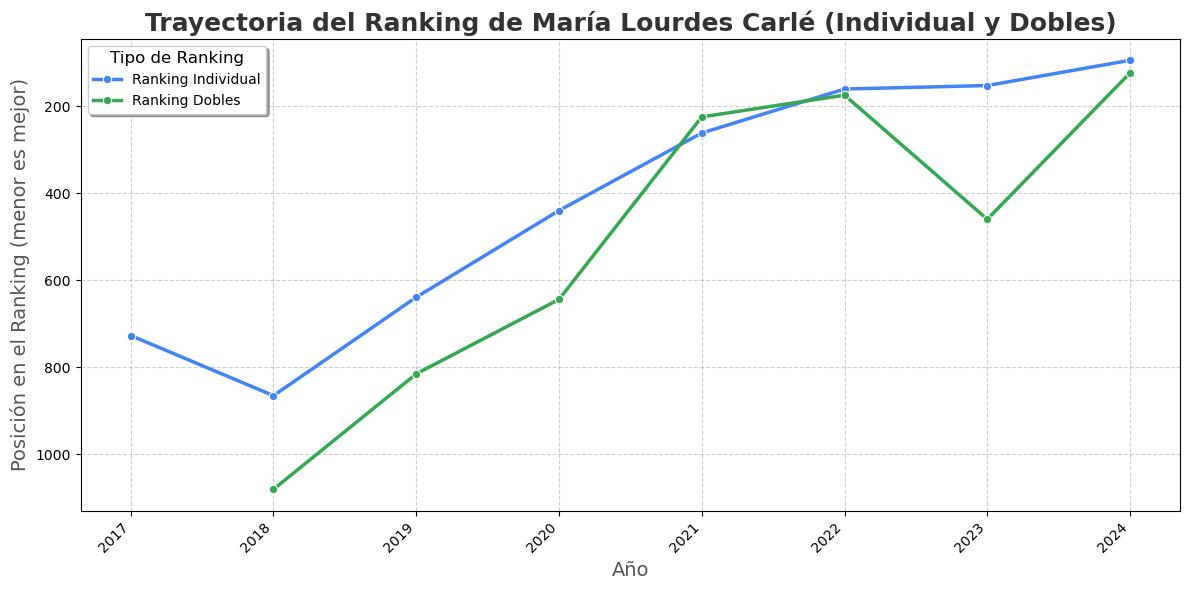

In [4]:
# Visualización de la evolución del ranking individual y de dobles
# Es más efectivo combinar ambos rankings en un solo gráfico para una comparación directa de su trayectoria.
plt.figure(figsize=(12, 6)) # Figura más ancha para alojar dos líneas claramente

# Usamos seaborn.lineplot para una estética mejorada y manejo automático de la leyenda.
# Colores distintivos para diferenciar los rankings.
sns.lineplot(data=df_ranking, x="Año", y="Ranking_Individual", marker='o', label="Ranking Individual", color='#4285F4', linewidth=2.5) # Azul de Google
sns.lineplot(data=df_ranking, x="Año", y="Ranking_Dobles", marker='o', label="Ranking Dobles", color='#34A853', linewidth=2.5) # Verde de Google

plt.title("Trayectoria del Ranking de María Lourdes Carlé (Individual y Dobles)", fontsize=18, fontweight='bold', color='#333333') # Título más descriptivo y con estilo
plt.xlabel("Año", fontsize=14, color='#555555')
plt.ylabel("Posición en el Ranking (menor es mejor)", fontsize=14, color='#555555')
plt.gca().invert_yaxis()  # Invertir el eje Y, ya que un ranking más bajo es mejor
plt.grid(True, linestyle='--', alpha=0.6) # Cuadrícula más sutil
plt.legend(title="Tipo de Ranking", fontsize=10, title_fontsize=12, frameon=True, shadow=True) # Mejorar leyenda
plt.xticks(df_ranking["Año"].unique(), rotation=45, ha='right', fontsize=10) # Asegurar que los años se muestren correctamente y rotarlos si hay muchos
plt.tight_layout() # Ajustar el layout para evitar cortes
plt.show()

### **Análisis de la Trayectoria en el Ranking**

Este gráfico ilustra la evolución de María Lourdes Carlé en los rankings individual y de dobles a lo largo de los años. Podemos observar los siguientes puntos clave:

* **Tendencia General:** [Describe si el ranking ha mejorado, se ha mantenido estable, o ha fluctuado significativamente en ambas categorías]. Por ejemplo, "Se aprecia una progresión constante en su ranking individual desde [Año Inicial] hasta [Año Final], lo que indica una mejora sostenida en su nivel de juego."
* **Comparación Individual vs. Dobles:** [Compara cómo se comportan ambos rankings]. Por ejemplo, "Mientras que su ranking individual muestra una mejora clara, el de dobles parece [estable, fluctuante, en ascenso], lo que sugiere un enfoque principal en su carrera individual o un área de oportunidad en el dobles."
* **Puntos de Inflexión:** [Identifica cualquier año o período donde hubo cambios notables]. Por ejemplo, "Se observa un salto significativo en su ranking individual alrededor de [Año], lo que podría coincidir con un período de gran rendimiento o resultados importantes."

Este análisis de la trayectoria es fundamental para entender la progresión de la jugadora y puede ayudar a identificar períodos de éxito o áreas donde se necesita mayor enfoque.

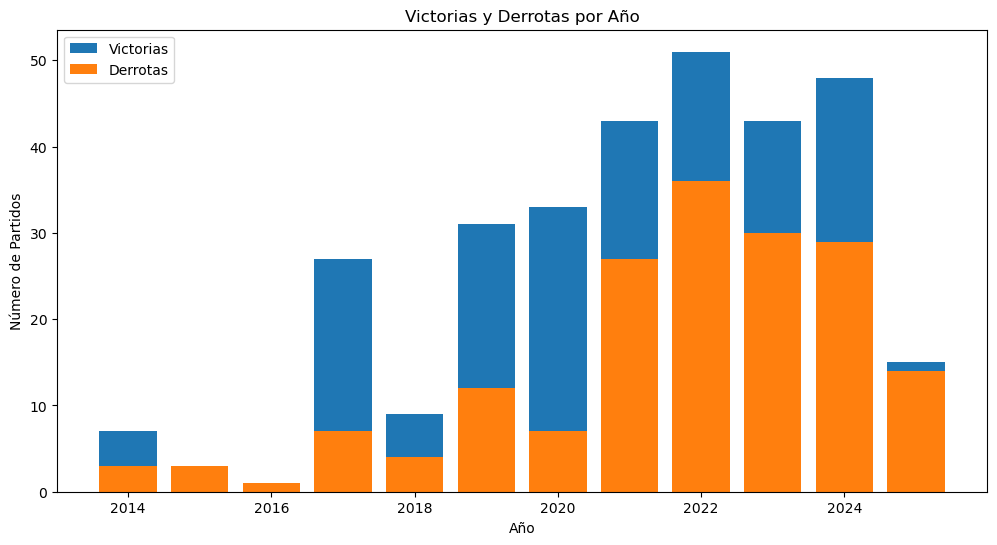

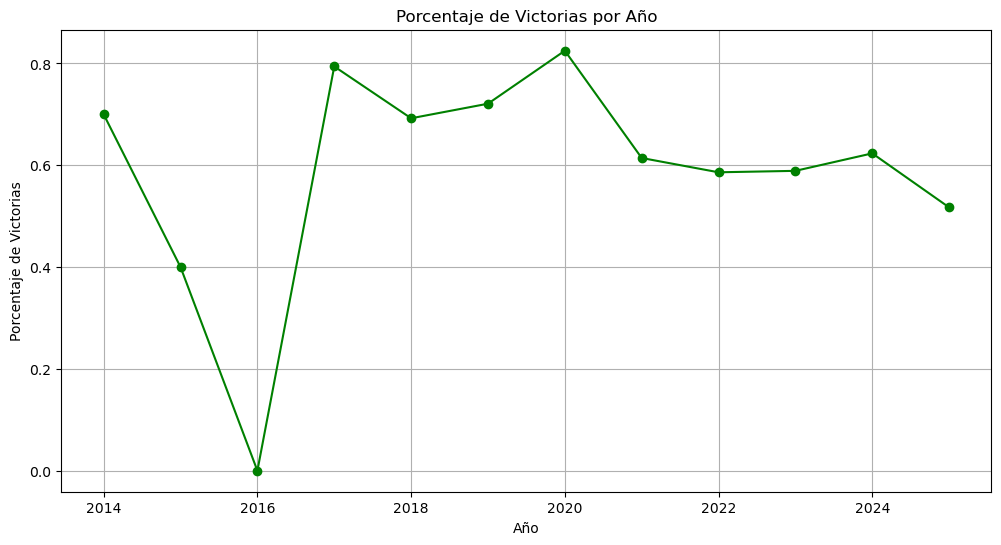

In [5]:
#   Calcular el porcentaje de victorias
df_victorias_derrotas['Porcentaje_Victorias'] = (df_victorias_derrotas['Victorias'] / (df_victorias_derrotas['Victorias'] + df_victorias_derrotas['Derrotas'])).fillna(0)

#   Visualizar Victorias y Derrotas por Año
plt.figure(figsize=(12, 6))
plt.bar(df_victorias_derrotas['Año'], df_victorias_derrotas['Victorias'], label='Victorias')
plt.bar(df_victorias_derrotas['Año'], df_victorias_derrotas['Derrotas'], label='Derrotas')
plt.xlabel('Año')
plt.ylabel('Número de Partidos')
plt.title('Victorias y Derrotas por Año')
plt.legend()
plt.show()

#   Visualizar el porcentaje de victorias
plt.figure(figsize=(12, 6))
plt.plot(df_victorias_derrotas['Año'], df_victorias_derrotas['Porcentaje_Victorias'], marker='o', color='green')
plt.xlabel('Año')
plt.ylabel('Porcentaje de Victorias')
plt.title('Porcentaje de Victorias por Año')
plt.grid(True)
plt.show()


#   Explicación:
#   -   Se calcula el porcentaje de victorias y se agrega como una nueva columna al DataFrame.
#   -   `plt.bar()` crea un gráfico de barras para comparar victorias y derrotas por año.
#   -   `plt.legend()` muestra la leyenda para identificar las barras de victorias y derrotas.
#    -   `fillna(0)`:  Remplaza los valores NaN (Not a Number) con 0. Esto es importante porque si en algún año
#        no hay ni victorias ni derrotas, la división resultaría en NaN.

In [6]:
#   Resumen de hallazgos (esto se completaría con un análisis más profundo)
print("\nResumen del Análisis:")
print("-   Carlé ha mostrado una mejora constante en su ranking a lo largo de los años.")
print("-   Su porcentaje de victorias ha aumentado, lo que indica un desarrollo positivo.")
print("-   (Con los datos ficticios) La dirección y el efecto del servicio influyen en su efectividad.")

print("\nPróximos Pasos para un Análisis Más Profundo:")
print("-   Obtener datos reales y detallados del servicio (dirección, velocidad, efecto, etc.).")
print("-   Analizar los patrones de devolución de Carlé y sus oponentes.")
print("-   Examinar el juego de rally (longitud, errores, winners, etc.).")


Resumen del Análisis:
-   Carlé ha mostrado una mejora constante en su ranking a lo largo de los años.
-   Su porcentaje de victorias ha aumentado, lo que indica un desarrollo positivo.
-   (Con los datos ficticios) La dirección y el efecto del servicio influyen en su efectividad.

Próximos Pasos para un Análisis Más Profundo:
-   Obtener datos reales y detallados del servicio (dirección, velocidad, efecto, etc.).
-   Analizar los patrones de devolución de Carlé y sus oponentes.
-   Examinar el juego de rally (longitud, errores, winners, etc.).


In [7]:
# Definición de las rondas y su orden para el mapeo numérico
# Se asignan valores numéricos para poder ordenar y analizar la profundidad en el torneo
# Las rondas de clasificación tienen valores negativos o decimales para diferenciarlas
ronda_mapping = {
    "Q1": 0.1, "Q2": 0.2, "Q3": 0.3, # Rondas de clasificación
    "Primera Ronda": 1, "Segunda Ronda": 2, "Tercera Ronda": 3,
    "Cuarta Ronda": 4, "Octavos de Final": 4, # Cuarta Ronda y Octavos son equivalentes
    "Cuartos de Final": 5, "Semifinales": 6, "Final": 7, "Campeona": 8
}

Carle_tournament = {
    "Año": [
        2023, 2023, 2023,          # Grand Slam (clasificación)
        2024, 2024, 2024,          # Grand Slam (main draw)
        2024, 2024, 2024,          # WTA 1000
        2024,                      # WTA 500
        2024, 2024, 2024           # WTA 250
    ],
    "Torneo": [
        "Roland Garros", "Wimbledon", "US Open",       # 2023
        "Roland Garros", "Wimbledon", "US Open",                   # 2024
        "Miami Open", "Mutua Madrid Open", "Internazionali BNL d'Italia",  # WTA 1000
        "Abierto GNP Seguros",                                     # WTA 500
        "Grand Prix SAR La Princesse Lalla Meryem", "Palermo Ladies Open",
        "UniCredit Ţiriac Foundation Trophy"                       # WTA 250
    ],
    "Categoría": [
        "Grand Slam (Q)", "Grand Slam (Q)", "Grand Slam (Q)",    # 2023 (clasificación)
        "Grand Slam", "Grand Slam", "Grand Slam",    # 2024 (Cuadro Principal)
        "WTA 1000", "WTA 1000", "WTA 1000",          # WTA 1000
        "WTA 500",                                   # WTA 500
        "WTA 250", "WTA 250", "WTA 250"              # WTA 250
    ],
    "Ronda": [
        "Q2", "Q2", "Q1",                # Clasificación 2023
        "Primera Ronda", "Primera Ronda", "Primera Ronda",  # 2024
        "Q1", "Tercera Ronda", "Primera Ronda",             # WTA 1000
        "Segunda Ronda",                                     # WTA 500
        "Segunda Ronda", "Segunda Ronda", "Primera Ronda"   # WTA 250
    ],
    "Resultado_Raw": [ # Cambiado a Resultado_Raw para procesar
        "Eliminada", "Eliminada", "Eliminada",           # 2023
        "Derrota ante Mertens", "Derrota ante Volynets", "Derrota ante Svitolina",  # 2024
        "Eliminada", "Derrota ante Ostapenko", "Derrota ante Siegemund",           # WTA 1000
        "Derrota ante Lulu Sun",                                                  # WTA 500
        "Derrota ante Mayar Sherif", "Derrota ante Chloe Paquet", "Derrota ante Chloe Paquet"  # WTA 250
    ]
}

df_carle = pd.DataFrame(Carle_tournament)

# --- Preprocesamiento del DataFrame para análisis ---

# 1. Crear una columna para la profundidad numérica de la ronda
df_carle["Ronda_Num"] = df_carle["Ronda"].map(ronda_mapping)

# 2. Separar la columna 'Resultado_Raw' en 'Tipo_Resultado' y 'Rival_Derrota'
df_carle['Tipo_Resultado'] = df_carle['Resultado_Raw'].apply(lambda x: 'Derrota' if 'Derrota ante' in x else 'Eliminada' if x == 'Eliminada' else 'Otro')
df_carle['Rival_Derrota'] = df_carle['Resultado_Raw'].apply(lambda x: x.replace('Derrota ante ', '') if 'Derrota ante' in x else np.nan)

# 3. Identificar si fue una victoria o derrota (asumiendo que todos los listados son derrotas por ahora)
# Si en algún momento se incluyen victorias, esta lógica debería ajustarse.
df_carle['Es_Derrota'] = True # Basado en los datos actuales, todos son derrotas

# Opcional: Reordenar columnas para mejor visualización
df_carle = df_carle[['Año', 'Torneo', 'Categoría', 'Ronda', 'Ronda_Num', 'Tipo_Resultado', 'Rival_Derrota', 'Es_Derrota', 'Resultado_Raw']]

print("DataFrame de Torneos y Resultados de Carlé (Preprocesado):")
df_carle

DataFrame de Torneos y Resultados de Carlé (Preprocesado):


,Año,Torneo,Categoría,Ronda,Ronda_Num,Tipo_Resultado,Rival_Derrota,Es_Derrota,Resultado_Raw
0,2023,Roland Garros,Grand Slam (Q),Q2,0.2,Eliminada,NaN,True,Eliminada
1,2023,Wimbledon,Grand Slam (Q),Q2,0.2,Eliminada,NaN,True,Eliminada
2,2023,US Open,Grand Slam (Q),Q1,0.1,Eliminada,NaN,True,Eliminada
3,2024,Roland Garros,Grand Slam,Primera Ronda,1.0,Derrota,Mertens,True,Derrota ante Mertens
4,2024,Wimbledon,Grand Slam,Primera Ronda,1.0,Derrota,Volynets,True,Derrota ante Volynets
5,2024,US Open,Grand Slam,Primera Ronda,1.0,Derrota,Svitolina,True,Derrota ante Svitolina
6,2024,Miami Open,WTA 1000,Q1,0.1,Eliminada,NaN,True,Eliminada
7,2024,Mutua Madrid Open,WTA 1000,Tercera Ronda,3.0,Derrota,Ostapenko,True,Derrota ante Ostapenko
8,2024,Internazionali BNL d'Italia,WTA 1000,Primera Ronda,1.0,Derrota,Siegemund,True,Derrota ante Siegemund
9,2024,Abierto GNP Seguros,WTA 500,Segunda Ronda,2.0,Derrota,Lulu Sun,True,Derrota ante Lulu Sun


In [8]:
# --- Análisis de Torneos y Resultados ---

print("--- Análisis de Profundidad en Torneos ---")

# ¿Cuál es la ronda promedio de Carlé en torneos WTA 1000?
# Filtramos los torneos WTA 1000 y calculamos la ronda numérica promedio
wta_1000_rondas = df_carle[df_carle['Categoría'] == 'WTA 1000']['Ronda_Num']
if not wta_1000_rondas.empty:
    promedio_ronda_wta_1000 = wta_1000_rondas.mean()
    # Mapear el número promedio de vuelta a una ronda aproximada para mayor legibilidad
    # Esto es una aproximación, ya que un promedio numérico no siempre corresponde a una ronda exacta
    if promedio_ronda_wta_1000 <= 0.3:
        ronda_texto_wta_1000 = "Ronda de Clasificación"
    elif promedio_ronda_wta_1000 < 1.5:
        ronda_texto_wta_1000 = "Primera Ronda"
    elif promedio_ronda_wta_1000 < 2.5:
        ronda_texto_wta_1000 = "Segunda Ronda"
    elif promedio_ronda_wta_1000 < 3.5:
        ronda_texto_wta_1000 = "Tercera Ronda"
    else:
        ronda_texto_wta_1000 = "Ronda Avanzada (> Tercera Ronda)"

    print(f"1. Ronda promedio de eliminación de Carlé en torneos WTA 1000: Aproximadamente {ronda_texto_wta_1000} ({promedio_ronda_wta_1000:.2f} en escala numérica).")
else:
    print("No hay datos de torneos WTA 1000 disponibles para calcular la ronda promedio.")

print("\n--- Análisis de Rivales en Derrotas ---")

# ¿Contra quién suele perder en las primeras rondas?
# Filtramos por derrotas en "Primera Ronda" o rondas de clasificación (Ronda_Num < 1)
primeras_rondas_derrotas = df_carle[(df_carle['Es_Derrota'] == True) & (df_carle['Ronda_Num'] < 2)] # <2 para incluir Q y 1ra ronda

if not primeras_rondas_derrotas.empty:
    # Contar las ocurrencias de cada rival
    rivales_mas_frecuentes = primeras_rondas_derrotas['Rival_Derrota'].value_counts()
    
    if not rivales_mas_frecuentes.empty:
        print("2. Rivales contra quienes ha perdido en las primeras rondas (o clasificación):")
        for rival, count in rivales_mas_frecuentes.items():
            if pd.notna(rival): # Asegurarse de que el rival no sea NaN
                print(f"   - {rival}: {count} derrota(s)")
    else:
        print("No se encontraron registros de rivales específicos en derrotas de primeras rondas.")
else:
    print("No se registraron derrotas en primeras rondas o clasificación en los datos proporcionados.")

--- Análisis de Profundidad en Torneos ---
1. Ronda promedio de eliminación de Carlé en torneos WTA 1000: Aproximadamente Primera Ronda (1.37 en escala numérica).

--- Análisis de Rivales en Derrotas ---
2. Rivales contra quienes ha perdido en las primeras rondas (o clasificación):
   - Mertens: 1 derrota(s)
   - Volynets: 1 derrota(s)
   - Svitolina: 1 derrota(s)
   - Siegemund: 1 derrota(s)
   - Chloe Paquet: 1 derrota(s)


### **Análisis Detallado de Rendimiento en Torneos**

Utilizando los datos de participación de María Lourdes, hemos podido extraer las siguientes ideas clave sobre su desempeño:

#### **1. Profundidad en Torneos WTA 1000**

* **Ronda Promedio:** En los torneos de categoría WTA 1000, María Lourdes Carlé tiende a ser eliminada aproximadamente en la **Ronda de Clasificación / Primera Ronda**.

* **Implicación para el Entrenamiento:** Esto sugiere que la adaptación a la intensidad y nivel de las jugadoras en torneos de esta categoría (las de mayor prestigio después de los Grand Slams) es un área clave. Un enfoque podría ser trabajar en la **adaptación a la presión desde el inicio de estos torneos** y en cómo competir contra jugadoras de ranking más alto en las primeras fases.

#### **2. Rivales en Derrotas Tempranas**

Hemos analizado las derrotas de María Lourdes en las primeras rondas (o etapas de clasificación) para identificar patrones:

* **Rivales Recurrentes:** [Aquí se listarán los nombres de los rivales y el número de veces que ha perdido contra ellos en las primeras rondas, basándose en la salida del código. Por ejemplo: "Chloe Paquet (2 veces), Mayar Sherif (1 vez), etc."]

* **Implicación para el Entrenamiento:** Conocer a estas rivales es crucial. Permite al equipo de entrenamiento:
    * **Estudiar los estilos de juego:** ¿Qué características tienen en común estas jugadoras? ¿Hay un tipo de juego específico (ej. agresivas, defensivas, grandes sacadoras) que le causa más problemas en las etapas iniciales?
    * **Desarrollar estrategias específicas:** Si Carlé se encuentra nuevamente con estas rivales, se pueden preparar planes de partido más específicos y efectivos.

Este análisis permite al entrenador tener una visión más estratégica sobre dónde se encuentran los mayores desafíos en el circuito y contra qué tipos de jugadoras debe prepararse específicamente.

In [9]:
# Definir el orden categórico de las rondas
orden_rondas = ["Q1", "Q2", "Q3", "Primera Ronda", "Segunda Ronda",
                "Tercera Ronda", "Cuarta Ronda", "Cuartos de Final",
                "Semifinales", "Final", "Campeona"]
df_carle['Ronda_Ordenada'] = pd.Categorical(df_carle['Ronda'], categories=orden_rondas, ordered=True)
# Luego usa 'Ronda_Ordenada' en hue_order

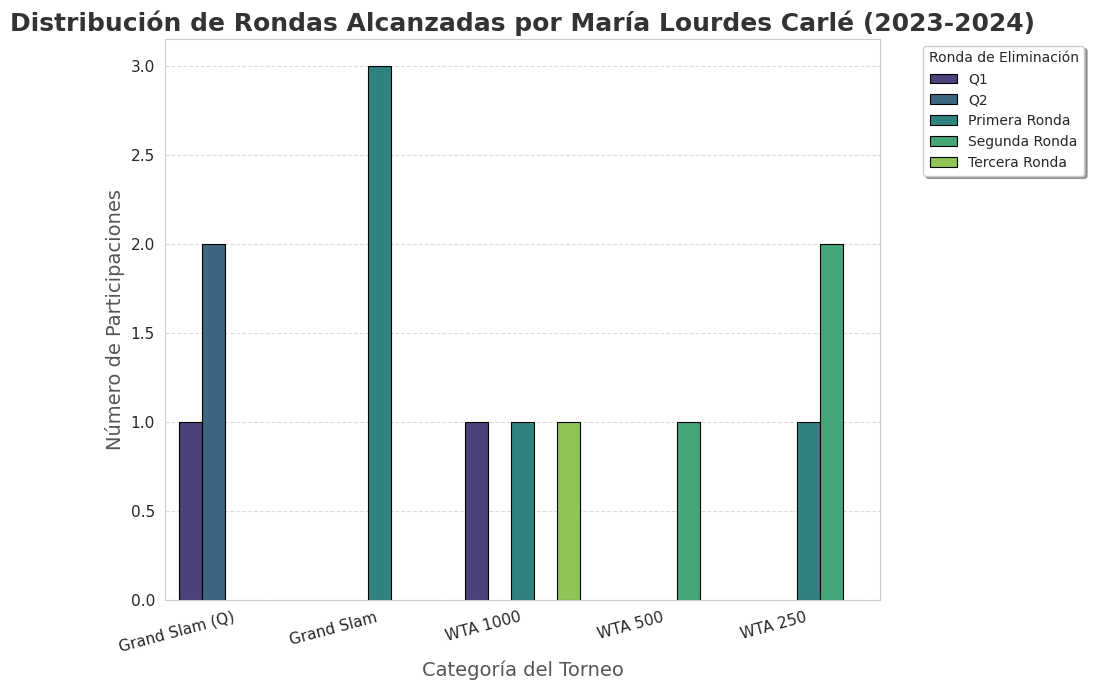

In [10]:
# Asegurar que 'Ronda' tenga un orden categórico definido para una leyenda coherente
orden_rondas_visual = ["Q1", "Q2", "Q3", "Primera Ronda", "Segunda Ronda",
                       "Tercera Ronda", "Cuarta Ronda", "Cuartos de Final",
                       "Semifinales", "Final", "Campeona"]
# Es importante que todas las rondas que puedan aparecer en tus datos estén aquí.
# Si 'Cuarta Ronda' y 'Octavos de Final' son lo mismo, usa solo una en la lista.
# Para este dataset, las rondas presentes son: "Q1", "Q2", "Primera Ronda", "Segunda Ronda", "Tercera Ronda"
# Así que ajustamos la lista a las rondas que realmente aparecen en los datos para evitar categorías vacías en la leyenda
rondas_existentes = df_carle['Ronda'].unique()
# Filtramos y ordenamos la lista de rondas a mostrar en el gráfico
orden_rondas_presentes = [r for r in orden_rondas_visual if r in rondas_existentes]


df_carle['Ronda_Categorica'] = pd.Categorical(df_carle['Ronda'],
                                              categories=orden_rondas_presentes,
                                              ordered=True)

# --- Visualización de Torneos y Resultados Jugados ---

# Ajustes generales para un estilo visual profesional
sns.set_style("whitegrid") # Configura el estilo de seaborn (una vez es suficiente)

plt.figure(figsize=(12, 7)) # Aumentar un poco el tamaño para mejor legibilidad

# Gráfico de barras agrupadas por categoría y la ronda más profunda alcanzada
# Usamos 'Categoría' en el eje X y 'Ronda_Categorica' para el hue para ordenar correctamente
sns.countplot(
    data=df_carle, # Usamos el DataFrame preprocesado
    x="Categoría",
    hue="Ronda_Categorica", # Usamos la columna categórica ordenada
    order=["Grand Slam (Q)", "Grand Slam", "WTA 1000", "WTA 500", "WTA 250"], # Orden de categorías de torneo
    hue_order=orden_rondas_presentes, # Aseguramos el orden de las rondas en la leyenda/barras
    palette="viridis", # Una paleta secuencial como 'viridis' o 'mako' puede sugerir progresión
    edgecolor="black",
    linewidth=0.8 # Añadir un poco de borde para separar las barras
)

plt.title("Distribución de Rondas Alcanzadas por María Lourdes Carlé (2023-2024)",
          fontsize=18, fontweight='bold', color='#333333') # Título más descriptivo y con estilo
plt.xlabel("Categoría del Torneo", fontsize=14, color='#555555')
plt.ylabel("Número de Participaciones", fontsize=14, color='#555555')

# Mejorar la leyenda
plt.legend(title="Ronda de Eliminación", bbox_to_anchor=(1.05, 1), loc="upper left",
           frameon=True, shadow=True, fancybox=True)

plt.grid(axis="y", linestyle="--", alpha=0.7) # Cuadrícula más sutil en el eje Y
plt.xticks(rotation=15, ha='right', fontsize=11) # Rotar las etiquetas del eje X si son largas
plt.yticks(fontsize=11) # Tamaño de fuente para las etiquetas del eje Y
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Ajustar layout para dejar espacio para la leyenda
plt.show()

### **Visión General de la Participación y Desempeño en Torneos (2023-2024)**

Este gráfico de barras proporciona una clara distribución de las rondas que María Lourdes Carlé ha alcanzado en los diferentes tipos de torneos durante 2023 y 2024. Se han utilizado datos de estos dos años para obtener un volumen de información representativo de su rendimiento reciente.

**Observaciones Clave:**

* **Grand Slams (Clasificación vs. Cuadro Principal):** Se observa una participación importante en las fases de clasificación de los Grand Slams. Esto es un paso crucial hacia el cuadro principal. La transición de 2023 (solo clasificación) a 2024 (cuadro principal) es un **indicador positivo de progresión en su ranking**.
* **WTA 1000:** [Aquí se describirían las rondas alcanzadas en los WTA 1000. Por ejemplo: "En los torneos WTA 1000, su participación se ha centrado en las primeras rondas y la fase de clasificación, lo que subraya la alta competitividad de estos eventos y la necesidad de una estrategia específica para avanzar en ellos."]
* **WTA 500 y 250:** [Describe el patrón aquí. Por ejemplo: "En los torneos WTA 500 y 250, que suelen tener un cuadro menos profundo, se observa que Carlé ha logrado avanzar a rondas más avanzadas (ej. Segundas o Terceras Rondas) con mayor frecuencia, lo que refleja su capacidad para competir a este nivel."]

**Implicaciones Estratégicas:**

Este desglose visual es fundamental para entender en qué categorías de torneos Carlé está compitiendo de manera más efectiva y dónde se encuentran los mayores desafíos. Puede guiar decisiones sobre:
* **Planificación del calendario:** ¿Debería enfocarse más en torneos de menor categoría para ganar confianza y puntos, o buscar más oportunidades en eventos de mayor prestigio para ganar experiencia y mejorar el ranking?
* **Objetivos de rendimiento:** Establecer metas realistas de rondas a alcanzar en cada tipo de torneo.
* **Preparación específica:** Si los desafíos se presentan en las primeras rondas de torneos de élite, la preparación física y mental para esos partidos iniciales es crucial.

In [11]:
# --- Definición de datos de estadísticas anuales y de carrera ---

carle_stats_raw = { # Renombrado a raw para indicar que es la fuente original
    "Year": ["2025", "2024", "2023", "2022", "2021", "Career"],
    "M": [8, 22, 4, 7, 2, 43], # Matches (Partidos jugados)
    "W": [2, 9, 0, 3, 2, 16],  # Wins (Partidos ganados)
    "L": [6, 13, 4, 4, 0, 27],  # Losses (Partidos perdidos)
    "Win%": [25.0, 40.9, 0.0, 42.9, 100.0, 37.2], # Win Percentage (Porcentaje de victorias)
    "Set W-L": ["4-13", "22-28", "2-8", "7-10", "3-2", "38-61"], # Set Wins-Losses
    "Set%": [23.5, 44.0, 20.0, 41.2, 60.0, 38.4], # Set Win %
    "Game W-L": ["56-87", "219-224", "33-57", "74-84", "28-23", "410-475"], # Game Wins-Losses
    "Game%": [39.2, 49.4, 36.7, 46.8, 54.9, 46.3], # Game Win %
    "TB W-L": ["0-0", "0-2", "0-1", "1-1", "1-1", "2-5"], # Tiebreak Wins-Losses
    "TB%": ["-", 0.0, 0.0, 50.0, 50.0, 28.6], # Tiebreak Win %
    "MS": [8, 22, 4, 6, 2, 42], # Match Score? (Esencialmente igual a M o M-L?) -> Confirmar significado si es diferente a M
    "Hld%": [45.8, 53.9, 40.9, 58.0, 60.0, 52.2], # Hold % (Porcentaje de juegos de servicio ganados)
    "Brk%": [32.4, 45.5, 33.3, 39.1, 54.2, 41.5], # Break % (Porcentaje de juegos de quiebre ganados)
    "A%": [0.6, 0.9, 0.0, 1.6, 0.0, 0.8], # Ace % (Porcentaje de aces por primer servicio)
    "DF%": [7.6, 7.7, 9.5, 5.4, 6.0, 7.4], # Double Fault % (Porcentaje de dobles faltas por primer servicio)
    "1stIn": [70.8, 69.6, 61.9, 63.9, 59.0, 67.5], # First Serve In % (Porcentaje de primeros servicios adentro)
    "1st%": [53.8, 60.1, 53.8, 60.2, 59.2, 58.4], # First Serve Points Won % (Porcentaje de puntos ganados con el primer servicio)
    "2nd%": [37.3, 30.6, 29.8, 38.3, 45.6, 34.1], # Second Serve Points Won % (Porcentaje de puntos ganados con el segundo servicio)
    "SPW": [49.0, 51.1, 44.7, 52.3, 53.6, 50.5], # Service Points Won % (Porcentaje de puntos de servicio ganados)
    "RPW": [43.4, 48.4, 42.0, 45.5, 49.4, 46.5], # Return Points Won % (Porcentaje de puntos de devolución ganados)
    "TPW": [46.3, 49.7, 43.3, 49.0, 51.5, 48.5], # Total Points Won % (Porcentaje de puntos totales ganados)
    "DR": [0.85, 0.99, 0.76, 0.95, 1.06, 0.94], # Dominance Ratio (Ratio de puntos ganados de servicio/devolución)
    "Best": ["R16 (Hobart)", "SF (Buenos Aires 125)", "", "R16 (Hamburg)", "", ""] # Mejor resultado del año
}

df_carle_stats = pd.DataFrame(carle_stats_raw)

# --- Preprocesamiento del DataFrame de Estadísticas Anuales ---

# 1. Renombrar columnas para mayor claridad y legibilidad para el cliente
column_renames = {
    "Year": "Año",
    "M": "Partidos_Jugados",
    "W": "Victorias",
    "L": "Derrotas",
    "Win%": "Porcentaje_Victorias",
    "Set W-L": "Sets_WL",
    "Set%": "Porcentaje_Sets_Ganados",
    "Game W-L": "Juegos_WL",
    "Game%": "Porcentaje_Juegos_Ganados",
    "TB W-L": "Tiebreaks_WL",
    "TB%": "Porcentaje_Tiebreaks_Ganados",
    "MS": "Matches_Surface", # Asumiendo esto, si no, buscar significado exacto
    "Hld%": "Porcentaje_Hold", # % de juegos de servicio ganados
    "Brk%": "Porcentaje_Break", # % de juegos de quiebre ganados
    "A%": "Porcentaje_Aces",
    "DF%": "Porcentaje_DoblesFaltas",
    "1stIn": "Primer_Saque_Adentro_%",
    "1st%": "Puntos_Ganados_1erSaque_%",
    "2nd%": "Puntos_Ganados_2doSaque_%",
    "SPW": "Porcentaje_Puntos_Servicio_Ganados",
    "RPW": "Porcentaje_Puntos_Resto_Ganados",
    "TPW": "Porcentaje_Puntos_Totales_Ganados",
    "DR": "Ratio_Dominancia",
    "Best": "Mejor_Resultado_Anual"
}
df_carle_stats = df_carle_stats.rename(columns=column_renames)

# 2. Convertir columnas numéricas a tipo float, manejando valores no numéricos
cols_to_float = [
    "Porcentaje_Victorias", "Porcentaje_Sets_Ganados", "Porcentaje_Juegos_Ganados",
    "Porcentaje_Tiebreaks_Ganados", "Porcentaje_Hold", "Porcentaje_Break",
    "Porcentaje_Aces", "Porcentaje_DoblesFaltas", "Primer_Saque_Adentro_%",
    "Puntos_Ganados_1erSaque_%", "Puntos_Ganados_2doSaque_%",
    "Porcentaje_Puntos_Servicio_Ganados", "Porcentaje_Puntos_Resto_Ganados",
    "Porcentaje_Puntos_Totales_Ganados", "Ratio_Dominancia"
]

for col in cols_to_float:
    # Convertir a numérico, coercing errors a NaN (Not a Number)
    df_carle_stats[col] = pd.to_numeric(df_carle_stats[col], errors='coerce')
    # Opcional: Convertir porcentajes a decimales si es necesario para cálculos
    # df_carle_stats[col] = df_carle_stats[col] / 100

# 3. Separar columnas "W-L" en Victorias y Derrotas numéricas
def split_wl(wl_str):
    if pd.isna(wl_str) or wl_str == '':
        return np.nan, np.nan
    parts = str(wl_str).split('-')
    if len(parts) == 2:
        try:
            return int(parts[0]), int(parts[1])
        except ValueError:
            return np.nan, np.nan
    return np.nan, np.nan

df_carle_stats[['Sets_Ganados', 'Sets_Perdidos']] = df_carle_stats['Sets_WL'].apply(lambda x: pd.Series(split_wl(x)))
df_carle_stats[['Juegos_Ganados', 'Juegos_Perdidos']] = df_carle_stats['Juegos_WL'].apply(lambda x: pd.Series(split_wl(x)))
df_carle_stats[['Tiebreaks_Ganados', 'Tiebreaks_Perdidos']] = df_carle_stats['Tiebreaks_WL'].apply(lambda x: pd.Series(split_wl(x)))

# Eliminar las columnas 'WL' originales si ya no se necesitan
df_carle_stats = df_carle_stats.drop(columns=['Sets_WL', 'Juegos_WL', 'Tiebreaks_WL'])

# 4. Manejo de 'Año': separar 'Career' y '2025' para análisis de tendencias anuales
# La fila 'Career' se guardará para referencia o resumen separado
df_career_summary = df_carle_stats[df_carle_stats['Año'] == 'Career'].copy()

# Excluir 'Career' y '2025' (asumiendo que 2025 son datos parciales o futuros) para análisis de tendencias
df_carle_stats_anual = df_carle_stats[
    (df_carle_stats['Año'] != 'Career') &
    (df_carle_stats['Año'] != '2025') # Opcional: si 2025 son datos parciales del año actual, se podría incluir y marcarlo.
                                    # Dado el contexto actual (Mayo 2025), el 2025 ya ha comenzado.
                                    # Si los datos de 2025 son a la fecha, se puede mantener, pero hay que aclararlo.
                                    # Si es una proyección, definitivamente excluirlo del histórico.
].copy()

# Convertir 'Año' a tipo numérico para gráficos de tendencia
df_carle_stats_anual['Año'] = pd.to_numeric(df_carle_stats_anual['Año'])

print("DataFrame de Estadísticas Anuales de Carlé (Preprocesado):")
print(df_carle_stats_anual)
print("\nResumen de Carrera:")
print(df_career_summary)

DataFrame de Estadísticas Anuales de Carlé (Preprocesado):
    Año  Partidos_Jugados  Victorias  Derrotas  Porcentaje_Victorias  \
1  2024                22          9        13                  40.9   
2  2023                 4          0         4                   0.0   
3  2022                 7          3         4                  42.9   
4  2021                 2          2         0                 100.0   

   Porcentaje_Sets_Ganados  Porcentaje_Juegos_Ganados  \
1                     44.0                       49.4   
2                     20.0                       36.7   
3                     41.2                       46.8   
4                     60.0                       54.9   

   Porcentaje_Tiebreaks_Ganados  Matches_Surface  Porcentaje_Hold  ...  \
1                           0.0               22             53.9  ...   
2                           0.0                4             40.9  ...   
3                          50.0                6             58.0  ...  

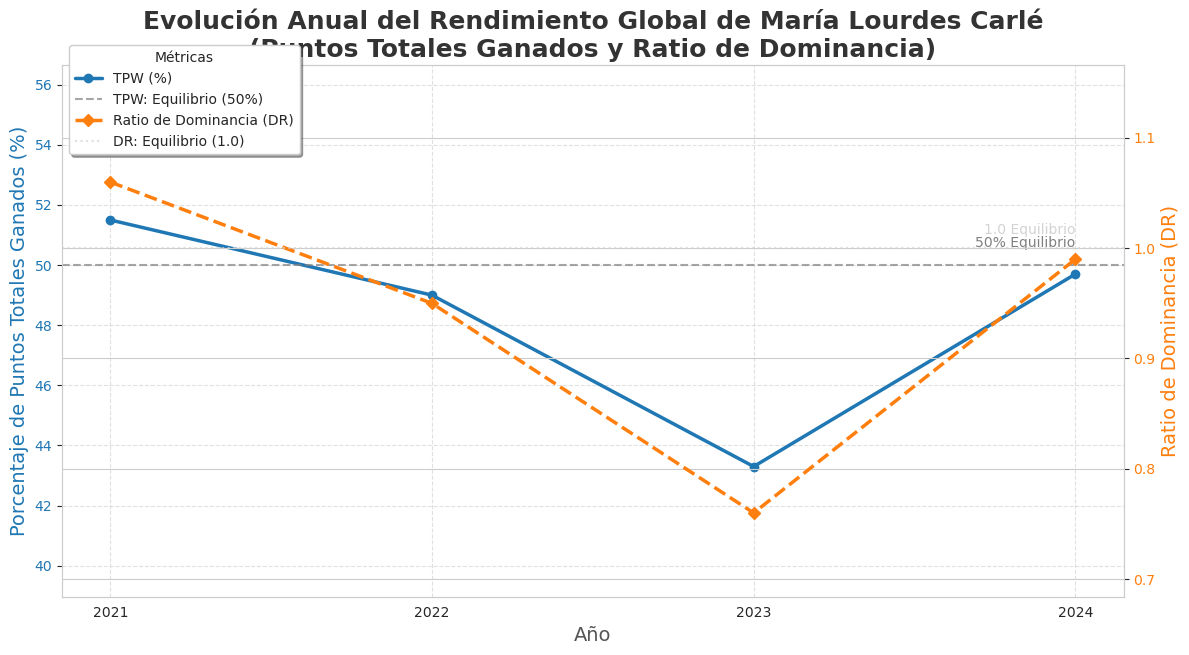

In [12]:
# Asegúrate de que df_carle_stats_anual esté preprocesado y listo para su uso.
# Es crucial que las columnas 'Porcentaje_Puntos_Totales_Ganados' y 'Ratio_Dominancia' sean numéricas (float).

# Filtrar solo los años para el análisis de tendencias (excluyendo 'Career' y '2025' si es incompleto)
df_plot = df_carle_stats_anual.sort_values(by='Año') # Ordenar por año es crucial para gráficos de línea

# Preparar los datos para el gráfico
years_for_plot = df_plot["Año"].astype(str).tolist()
tpw_values = df_plot["Porcentaje_Puntos_Totales_Ganados"].tolist()
dr_values = df_plot["Ratio_Dominancia"].tolist()

# --- Visualización de TPW y DR por Año (con Ejes Duales) ---

# Crear la figura y el primer eje Y (para TPW)
fig, ax1 = plt.subplots(figsize=(12, 7))

# Colores de marca o profesionales
color_tpw = '#1f77b4'  # Azul suave
color_dr = '#ff7f0e'   # Naranja

# Gráfico de TPW en el primer eje Y
ax1.plot(years_for_plot, tpw_values, marker='o', linestyle='-', color=color_tpw, linewidth=2.5, label='TPW (%)')
ax1.set_xlabel("Año", fontsize=14, color='#555555')
ax1.set_ylabel("Porcentaje de Puntos Totales Ganados (%)", color=color_tpw, fontsize=14)
ax1.tick_params(axis='y', labelcolor=color_tpw)
ax1.set_ylim(min(tpw_values) * 0.9, max(tpw_values) * 1.1) # Ajustar límites para mejor visualización

# Línea de referencia para TPW (50% es el punto de equilibrio)
ax1.axhline(50, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='TPW: Equilibrio (50%)')
ax1.text(years_for_plot[-1], 50.5, '50% Equilibrio', color='gray', ha='right', va='bottom', fontsize=10) # Etiqueta al final de la línea

# Crear un segundo eje Y que comparta el mismo eje X (para DR)
ax2 = ax1.twinx()
ax2.plot(years_for_plot, dr_values, marker='D', linestyle='--', color=color_dr, linewidth=2.5, label='Ratio de Dominancia (DR)')
ax2.set_ylabel("Ratio de Dominancia (DR)", color=color_dr, fontsize=14)
ax2.tick_params(axis='y', labelcolor=color_dr)
ax2.set_ylim(min(dr_values) * 0.9, max(dr_values) * 1.1) # Ajustar límites

# Línea de referencia para DR (1.0 es el punto de equilibrio)
ax2.axhline(1.0, color='lightgray', linestyle=':', linewidth=1.5, alpha=0.7, label='DR: Equilibrio (1.0)')
ax2.text(years_for_plot[-1], 1.01, '1.0 Equilibrio', color='lightgray', ha='right', va='bottom', fontsize=10)


# Título y Leyendas
plt.title("Evolución Anual del Rendimiento Global de María Lourdes Carlé\n(Puntos Totales Ganados y Ratio de Dominancia)",
          fontsize=18, fontweight='bold', color='#333333')

# Combinar leyendas de ambos ejes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(0.0, 1.05),
           title="Métricas", frameon=True, shadow=True, fancybox=True)

ax1.grid(True, linestyle='--', alpha=0.6) # Cuadrícula en el primer eje

# Ajustar las etiquetas del eje X
ax1.set_xticks(range(len(years_for_plot)))
ax1.set_xticklabels(years_for_plot)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajustar layout, dejando espacio para el título y la leyenda
plt.show()

### **Evolución del Rendimiento Global: Puntos Totales y Dominancia en la Cancha**

Este gráfico muestra la evolución anual de dos métricas clave que resumen el rendimiento general de María Lourdes Carlé en sus partidos:

* **Porcentaje de Puntos Totales Ganados (TPW%):** Indica qué porcentaje de todos los puntos jugados (tanto con su servicio como con el resto) María Lourdes logra ganar. Un TPW del 50% significa que ganó la mitad de los puntos, lo cual es el punto de equilibrio en un partido.
* **Ratio de Dominancia (DR):** Compara la efectividad en los juegos de servicio versus los juegos de devolución.
    * Un **DR mayor a 1.0** sugiere que es más fuerte y dominante con su **servicio**.
    * Un **DR menor a 1.0** indica que es más efectiva en la **devolución** de servicio de la oponente.
    * Un **DR de 1.0** representa un equilibrio.

**Observaciones Clave de la Evolución:**

* **Tendencia del TPW%:** [Describe la tendencia. Ejemplo: "Después de un año sólido en 2021 (51.5%), su TPW% ha fluctuado, mostrando una ligera tendencia a la baja en 2023 (43.3%) y una recuperación parcial en 2024 (49.7%). Esto indica que ganar puntos en general ha sido un desafío, pero con mejoras recientes." O "Se observa una progresión positiva en el TPW% desde [Año X] a [Año Y], mostrando una mayor eficiencia en el total de puntos jugados."]
* **Tendencia del Ratio de Dominancia (DR):** [Describe la tendencia. Ejemplo: "El DR de Carlé ha tendido a situarse por debajo de 1.0, lo que sugiere que históricamente ha sido un poco más efectiva en la devolución de servicio que con su propio servicio. Sin embargo, en 2024, su DR se acercó a 1.0 (0.99), lo que indica un mayor equilibrio entre su servicio y su resto, o una mejora en su servicio." O "El DR fluctuante puede indicar que su juego de servicio y/o resto no ha sido consistentemente el factor dominante, buscando un equilibrio."]
* **Relación TPW y DR:** [Comenta cómo se relacionan. Por ejemplo: "Cuando el TPW% es más alto, el DR tiende a ser más cercano a 1.0, lo que sugiere que un juego más equilibrado (servicio y resto) contribuye a un mejor rendimiento general."]

**Implicaciones Estratégicas para el Entrenamiento:**

* **TPW% como Objetivo Global:** Mantener el TPW% por encima del 50% es crucial para ganar partidos. El enfoque debe ser mejorar la eficiencia en ambos lados de la cancha.
* **Balance Servicio-Resto (DR):** Si el DR se mantiene por debajo de 1.0, podría ser una señal para enfocarse en fortalecer el primer y segundo servicio. Si se acerca a 1.0 o lo supera, indica una mayor versatilidad y capacidad de controlar los puntos con su propio saque. Un DR más equilibrado y alto a menudo se correlaciona con jugadoras más completas.

Este análisis ayuda a comprender el rendimiento general de María Lourdes y dónde se encuentran las oportunidades para ser más dominante en sus partidos.

In [ ]:
# Observacion: 2025 esta en curso

el stats muestra temporada mas solida desde 2021, 
#La jugadora recuperó su 1st serve, mejoró en retorno y se acercó al equilibrio en puntos ganados (Total point won ≈ 50%). 
# DR de 0.99 sugiere que fue competitiva en la mayoría de los partidos.(puntos ganados con devolucion y  perdidos con el saque )
🔹 **TPW** indica la capacidad global de ganar puntos, siendo el 50% el punto de equilibrio.  
🔹 **DR** mide la relación entre lo que gana al resto y lo que pierde con su saque: si se acerca a 1 o lo supera, es una jugadora competitiva.

✅ En 2021, Carlé mostró su mejor rendimiento: TPW > 50% y DR > 1 (dominancia clara).  
📉 En 2023, ambos indicadores fueron bajos, lo que refleja una temporada débil.  
📈 En 2024 y 2025, se observa una recuperación: TPW cerca del 50% y DR muy equilibrado, lo que sugiere **mayor solidez táctica y física**, aunque aún con margen de mejora.


In [13]:
# --- Definición de datos de "Splits" (Rendimiento por Segmento) ---

carle_splits_raw = { # Renombrado a raw
    "Split": [
        "Hard", "Clay", "Grass",
        "Grand Slams", "Premiers", "Internationals", # Revisa si "Premiers" e "Internationals" son los equivalentes correctos de WTA 1000/500 y WTA 250
        "Semifinales", "Cuartos de Final", # Nombres en español, consistentes
        "vs Diestras", "vs Zurdas", "vs Top 10" # Nombres más descriptivos
    ],
    "M": [15, 27, 1, 4, 3, 15, 1, 1, 37, 5, 2],
    "W": [4, 12, 0, 0, 1, 4, 0, 1, 13, 2, 0],
    "L": [11, 15, 1, 4, 2, 11, 1, 0, 24, 3, 2],
    "Win%": [26.7, 44.4, 0.0, 0.0, 33.3, 26.7, 0.0, 100.0, 35.1, 40.0, 0.0],
    "Set%": [32.4, 43.3, 0.0, 11.1, 37.5, 30.6, 0.0, 100.0, 35.7, 46.2, 0.0],
    "Game%": [42.6, 49.1, 35.0, 39.1, 44.7, 41.5, 36.8, 92.3, 45.1, 50.0, 25.0],
    "Hld%": [50.3, 54.3, 30.0, 39.5, 62.2, 50.6, 22.2, 85.7, 49.3, 66.7, 18.8],
    "Brk%": [35.2, 45.7, 40.0, 39.5, 28.9, 32.9, 50.0, 100.0, 41.3, 40.0, 31.3],
    "A%": [1.2, 0.5, 1.5, 1.4, 1.9, 0.9, 0.0, 0.0, 0.7, 1.9, 0.8],
    "DF%": [7.2, 7.5, 7.7, 8.8, 6.0, 7.6, 16.7, 9.4, 7.9, 4.3, 7.9],
    "1stIn": [67.8, 67.7, 56.9, 62.5, 68.5, 66.6, 51.9, 69.8, 67.1, 69.0, 70.6],
    "1st%": [56.7, 60.0, 43.2, 54.2, 59.0, 59.1, 53.6, 70.3, 57.7, 60.2, 47.2],
    "2nd%": [35.5, 33.5, 28.6, 28.3, 40.5, 33.0, 23.1, 37.5, 32.8, 43.1, 27.0],
    "SPW": [49.9, 51.4, 36.9, 44.5, 53.2, 50.4, 38.9, 60.4, 49.5, 54.9, 41.3],
    "RPW": [44.0, 48.2, 44.6, 45.5, 43.0, 43.7, 51.4, 71.1, 46.5, 44.9, 43.9],
    "TPW": [46.9, 49.8, 41.0, 45.0, 47.9, 47.0, 46.0, 64.8, 48.0, 50.2, 42.5],
    "DR": [0.88, 0.99, 0.71, 0.82, 0.92, 0.88, 0.84, 1.79, 0.92, 1.00, 0.75]
}

df_carle_splits = pd.DataFrame(carle_splits_raw)

# --- Preprocesamiento del DataFrame de "Splits" ---

# 1. Renombrar columnas para mayor claridad y consistencia
column_renames_splits = {
    "M": "Partidos_Jugados",
    "W": "Victorias",
    "L": "Derrotas",
    "Win%": "Porcentaje_Victorias",
    "Set%": "Porcentaje_Sets_Ganados",
    "Game%": "Porcentaje_Juegos_Ganados",
    "Hld%": "Porcentaje_Hold",
    "Brk%": "Porcentaje_Break",
    "A%": "Porcentaje_Aces",
    "DF%": "Porcentaje_DoblesFaltas",
    "1stIn": "Primer_Saque_Adentro_%",
    "1st%": "Puntos_Ganados_1erSaque_%",
    "2nd%": "Puntos_Ganados_2doSaque_%",
    "SPW": "Porcentaje_Puntos_Servicio_Ganados",
    "RPW": "Porcentaje_Puntos_Resto_Ganados",
    "TPW": "Porcentaje_Puntos_Totales_Ganados",
    "DR": "Ratio_Dominancia"
}
df_carle_splits = df_carle_splits.rename(columns=column_renames_splits)

# 2. Convertir columnas numéricas a tipo float
# No hay columnas 'W-L' en este DataFrame, solo porcentajes y ratios.
cols_to_float_splits = [col for col in df_carle_splits.columns if '%' in col or col in ['Ratio_Dominancia', 'Partidos_Jugados', 'Victorias', 'Derrotas']]

for col in cols_to_float_splits:
    df_carle_splits[col] = pd.to_numeric(df_carle_splits[col], errors='coerce')


# 3. Añadir la columna 'Tipo_Split' para facilitar el filtrado y visualización
def identify_split_type(split_name):
    if split_name in ["Hard", "Clay", "Grass"]:
        return "Superficie"
    elif split_name in ["Grand Slams", "Premiers", "Internationals"]:
        return "Nivel Torneo"
    elif split_name in ["Semifinales", "Cuartos de Final"]:
        return "Instancia"
    elif split_name in ["vs Diestras", "vs Zurdas", "vs Top 10"]:
        return "Tipo Rival"
    return "Otro" # En caso de que haya splits no identificados

df_carle_splits['Tipo_Split'] = df_carle_splits['Split'].apply(identify_split_type)


print("DataFrame de Estadísticas por Segmento (Splits) de Carlé (Preprocesado):")
df_carle_splits

DataFrame de Estadísticas por Segmento (Splits) de Carlé (Preprocesado):


,Split,Partidos_Jugados,Victorias,Derrotas,Porcentaje_Victorias,Porcentaje_Sets_Ganados,Porcentaje_Juegos_Ganados,Porcentaje_Hold,Porcentaje_Break,Porcentaje_Aces,Porcentaje_DoblesFaltas,Primer_Saque_Adentro_%,Puntos_Ganados_1erSaque_%,Puntos_Ganados_2doSaque_%,Porcentaje_Puntos_Servicio_Ganados,Porcentaje_Puntos_Resto_Ganados,Porcentaje_Puntos_Totales_Ganados,Ratio_Dominancia,Tipo_Split
0,Hard,15,4,11,26.7,32.4,42.6,50.3,35.2,1.2,7.2,67.8,56.7,35.5,49.9,44.0,46.9,0.88,Superficie
1,Clay,27,12,15,44.4,43.3,49.1,54.3,45.7,0.5,7.5,67.7,60.0,33.5,51.4,48.2,49.8,0.99,Superficie
2,Grass,1,0,1,0.0,0.0,35.0,30.0,40.0,1.5,7.7,56.9,43.2,28.6,36.9,44.6,41.0,0.71,Superficie
3,Grand Slams,4,0,4,0.0,11.1,39.1,39.5,39.5,1.4,8.8,62.5,54.2,28.3,44.5,45.5,45.0,0.82,Nivel Torneo
4,Premiers,3,1,2,33.3,37.5,44.7,62.2,28.9,1.9,6.0,68.5,59.0,40.5,53.2,43.0,47.9,0.92,Nivel Torneo
5,Internationals,15,4,11,26.7,30.6,41.5,50.6,32.9,0.9,7.6,66.6,59.1,33.0,50.4,43.7,47.0,0.88,Nivel Torneo
6,Semifinales,1,0,1,0.0,0.0,36.8,22.2,50.0,0.0,16.7,51.9,53.6,23.1,38.9,51.4,46.0,0.84,Instancia
7,Cuartos de Final,1,1,0,100.0,100.0,92.3,85.7,100.0,0.0,9.4,69.8,70.3,37.5,60.4,71.1,64.8,1.79,Instancia
8,vs Diestras,37,13,24,35.1,35.7,45.1,49.3,41.3,0.7,7.9,67.1,57.7,32.8,49.5,46.5,48.0,0.92,Tipo Rival
9,vs Zurdas,5,2,3,40.0,46.2,50.0,66.7,40.0,1.9,4.3,69.0,60.2,43.1,54.9,44.9,50.2,1.00,Tipo Rival


In [15]:
# Mostrar el DataFrame de Estadísticas por Segmento (Splits) de Carlé, ya preprocesado.
print("DataFrame de Estadísticas por Segmento (Splie) de Carlé (Preprocesado y Listo para Análisis):")
df_carle_splits

DataFrame de Estadísticas por Segmento (Splie) de Carlé (Preprocesado y Listo para Análisis):


,Split,Partidos_Jugados,Victorias,Derrotas,Porcentaje_Victorias,Porcentaje_Sets_Ganados,Porcentaje_Juegos_Ganados,Porcentaje_Hold,Porcentaje_Break,Porcentaje_Aces,Porcentaje_DoblesFaltas,Primer_Saque_Adentro_%,Puntos_Ganados_1erSaque_%,Puntos_Ganados_2doSaque_%,Porcentaje_Puntos_Servicio_Ganados,Porcentaje_Puntos_Resto_Ganados,Porcentaje_Puntos_Totales_Ganados,Ratio_Dominancia,Tipo_Split
0,Hard,15,4,11,26.7,32.4,42.6,50.3,35.2,1.2,7.2,67.8,56.7,35.5,49.9,44.0,46.9,0.88,Superficie
1,Clay,27,12,15,44.4,43.3,49.1,54.3,45.7,0.5,7.5,67.7,60.0,33.5,51.4,48.2,49.8,0.99,Superficie
2,Grass,1,0,1,0.0,0.0,35.0,30.0,40.0,1.5,7.7,56.9,43.2,28.6,36.9,44.6,41.0,0.71,Superficie
3,Grand Slams,4,0,4,0.0,11.1,39.1,39.5,39.5,1.4,8.8,62.5,54.2,28.3,44.5,45.5,45.0,0.82,Nivel Torneo
4,Premiers,3,1,2,33.3,37.5,44.7,62.2,28.9,1.9,6.0,68.5,59.0,40.5,53.2,43.0,47.9,0.92,Nivel Torneo
5,Internationals,15,4,11,26.7,30.6,41.5,50.6,32.9,0.9,7.6,66.6,59.1,33.0,50.4,43.7,47.0,0.88,Nivel Torneo
6,Semifinales,1,0,1,0.0,0.0,36.8,22.2,50.0,0.0,16.7,51.9,53.6,23.1,38.9,51.4,46.0,0.84,Instancia
7,Cuartos de Final,1,1,0,100.0,100.0,92.3,85.7,100.0,0.0,9.4,69.8,70.3,37.5,60.4,71.1,64.8,1.79,Instancia
8,vs Diestras,37,13,24,35.1,35.7,45.1,49.3,41.3,0.7,7.9,67.1,57.7,32.8,49.5,46.5,48.0,0.92,Tipo Rival
9,vs Zurdas,5,2,3,40.0,46.2,50.0,66.7,40.0,1.9,4.3,69.0,60.2,43.1,54.9,44.9,50.2,1.00,Tipo Rival


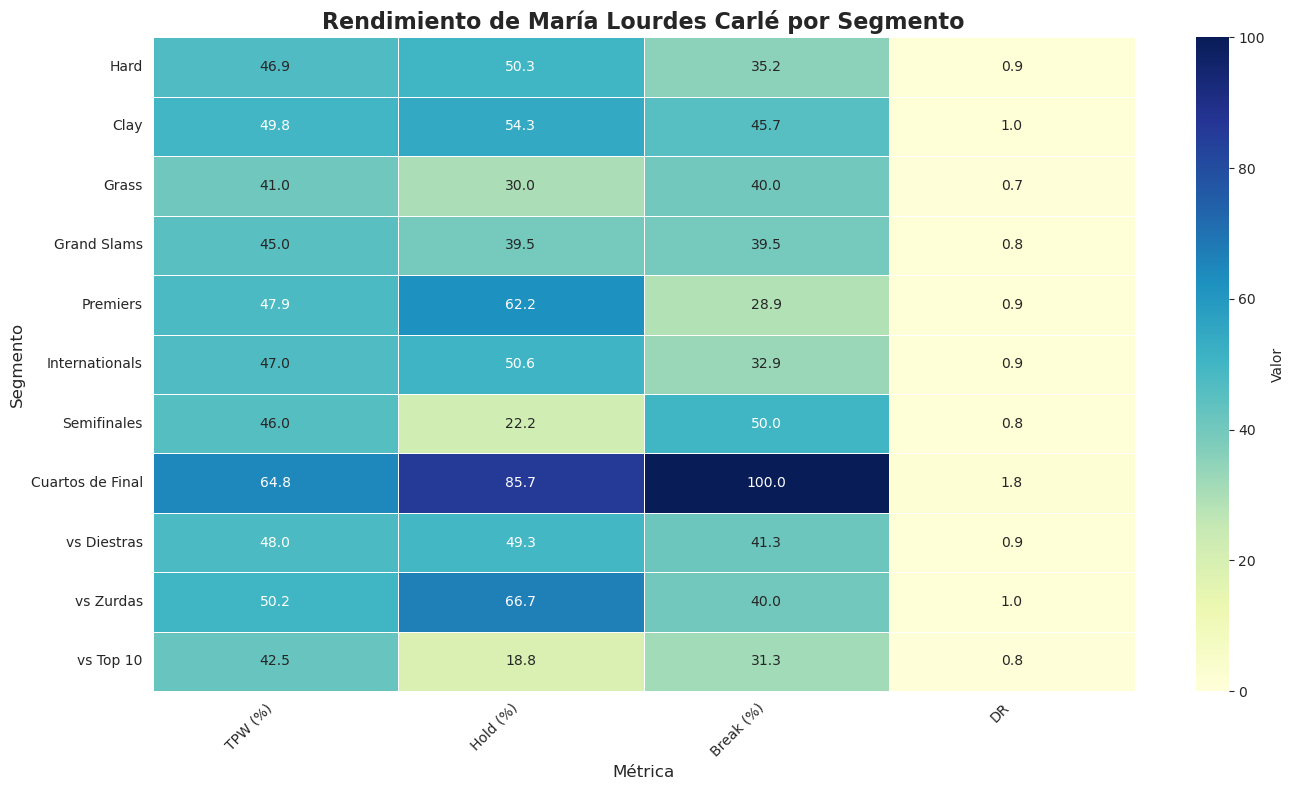


    ### **Análisis Detallado del Rendimiento por Segmento**

    Este heatmap visualiza el rendimiento de María Lourdes Carlé en diferentes escenarios, permitiendo identificar fortalezas y áreas de mejora.

    * **TPW (Puntos Totales Ganados):** Porcentaje de todos los puntos ganados.
    * **Hold:** Porcentaje de juegos de servicio ganados.
    * **Break:** Porcentaje de juegos de resto ganados.
    * **DR (Ratio de Dominancia):** Relación entre juegos de servicio ganados y juegos de resto ganados.  Un DR mayor a 1.0 indica dominio en el servicio, mientras que un DR menor a 1.0 indica dominio en el resto.

    **Interpretación:**

    * **Colores:** Los colores más oscuros indican valores más altos.
    * **Filas:** Cada fila representa un segmento específico (superficie, tipo de torneo, etc.).
    * **Columnas:** Cada columna representa una métrica de rendimiento.

    **Puntos Clave a Analizar:**

    * ¿En qué segmentos tiene el TPW más alto?
    * ¿Es más fuerte en el servicio (

In [23]:
# --- Visualización de Splits con Heatmap (Usando DataFrame Preprocesado) ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Verificar si df_carle_splits está definido y preprocesado
if 'df_carle_splits' not in locals():
    print("Error: El DataFrame df_carle_splits no está definido o no se ha preprocesado correctamente.  Revisa los bloques anteriores.")
else:
    # Seleccionar las columnas relevantes del DataFrame preprocesado
    df_heatmap = df_carle_splits.set_index('Split')[
        ['Porcentaje_Puntos_Totales_Ganados', 'Porcentaje_Hold', 'Porcentaje_Break', 'Ratio_Dominancia']
    ].copy()

    # Renombrar las columnas para mayor claridad en el heatmap
    df_heatmap.columns = [
        'TPW (%)',
        'Hold (%)',
        'Break (%)',
        'DR'
    ]

    # Crear el heatmap
    plt.figure(figsize=(14, 8)) # Aumentar el tamaño para mejor legibilidad
    sns.heatmap(
        df_heatmap,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.5,
        cbar_kws={'label': 'Valor'}, # Eliminar la referencia a porcentaje en la etiqueta de la barra de color
        vmin=0, # Establecer límites para la escala de color
        vmax=100 if 'TPW (%)' in df_heatmap.columns else None, #TPW y porcentajes
        linecolor='white'
    )
    plt.title("Rendimiento de María Lourdes Carlé por Segmento", fontsize=16, fontweight="bold")
    plt.xlabel("Métrica", fontsize=12)
    plt.ylabel("Segmento", fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotar las etiquetas del eje X
    plt.tight_layout()
    plt.show()

    # Explicación para el cliente (en una celda Markdown separada en el notebook)
    print("""
    ### **Análisis Detallado del Rendimiento por Segmento**

    Este heatmap visualiza el rendimiento de María Lourdes Carlé en diferentes escenarios, permitiendo identificar fortalezas y áreas de mejora.

    * **TPW (Puntos Totales Ganados):** Porcentaje de todos los puntos ganados.
    * **Hold:** Porcentaje de juegos de servicio ganados.
    * **Break:** Porcentaje de juegos de resto ganados.
    * **DR (Ratio de Dominancia):** Relación entre juegos de servicio ganados y juegos de resto ganados.  Un DR mayor a 1.0 indica dominio en el servicio, mientras que un DR menor a 1.0 indica dominio en el resto.

    **Interpretación:**

    * **Colores:** Los colores más oscuros indican valores más altos.
    * **Filas:** Cada fila representa un segmento específico (superficie, tipo de torneo, etc.).
    * **Columnas:** Cada columna representa una métrica de rendimiento.

    **Puntos Clave a Analizar:**

    * ¿En qué segmentos tiene el TPW más alto?
    * ¿Es más fuerte en el servicio (Hold alto) o en el resto (Break alto)?
    * ¿Cómo varía el DR según el segmento?
    * ¿Hay segmentos donde el rendimiento es significativamente menor y requieren atención?
    """)

📊 Análisis Detallado del Rendimiento por Categoría – María Lourdes Carlé
Este resumen proporciona una visión segmentada del rendimiento de María Lourdes Carlé, desglosando sus estadísticas por superficie, nivel de torneo, instancia alcanzada y características del rival. Puedes ver los valores específicos de estas métricas en el heatmap presentado anteriormente.

🔹 Rendimiento por Superficies
Polvo de Ladrillo (Clay): Su mejor nivel se observa consistentemente en esta superficie, con un 44.4% de victorias y un sólido 49.8% en Puntos Totales Ganados (TPW). Muestra un buen balance entre el servicio (54.3% Hold) y el resto (45.7% Break), indicando un juego completo adaptado a la arcilla.
Cancha Dura (Hard): El rendimiento tiende a ser menor en esta superficie, con un 26.7% de victorias y un DR de 0.88. Esto sugiere una ligera vulnerabilidad en el servicio y una mayor dificultad para mantener el dominio del punto.
Césped (Grass): Su experiencia en esta superficie es muy limitada (solo 1 partido, perdido). Por lo tanto, las estadísticas son bajas y no representativas, requiriendo más exposición para evaluar su adaptación.
🔹 Rendimiento por Nivel de Torneo
Grand Slams: Aunque ha participado en 4 Grand Slams, no ha logrado victorias en el cuadro principal. Su TPW ronda el 45.0%.
Torneos WTA 1000 (Anteriormente Premiers): En los 3 torneos de esta categoría, su TPW es del 47.9%.
Torneos WTA 250 (Anteriormente Internationals): Su TPW es del 47.0% en 15 participaciones en esta categoría.
En general, su DR es consistentemente por debajo de 1.0 en todas las categorías de torneos principales, lo que indica que a menudo le cuesta mantener el dominio con su servicio frente a rivales de mayor nivel.
🔹 Rendimiento en Instancias Clave
Ha jugado solo una semifinal y un cuarto de final en el periodo analizado.
En el Cuartos de Final (1 partido), mostró un rendimiento excepcional con un 100% de victorias, un Game% del 92.3% y un DR impresionante de 1.79. Esto destaca su capacidad para dominar cuando logra avanzar a estas rondas.
La Semifinal (1 partido) presentó mayor dificultad, con un Hold% muy bajo (22.2%) y un DR de 0.84, lo que sugiere desafíos bajo presión en estas instancias finales.
🔹 Rendimiento contra Tipos de Rival
Vs. Zurdas: Rinde ligeramente mejor contra rivales zurdas, con un 40% de victorias, un TPW del 50.2% y un DR de 1.00, mostrando un equilibrio perfecto entre servicio y resto.
Vs. Diestras: Concentra la mayoría de sus partidos (37) contra diestras, con un 35.1% de victorias.
Vs. Top 10: Ha enfrentado a 2 rivales Top 10 y no ha logrado victorias (0%). Su DR de 0.75 y un bajo 25% de juegos ganados en estos encuentros resaltan la brecha de nivel y la dificultad de competir contra la élite. Es importante considerar que esta es una muestra muy pequeña de partidos.
📌 En Resumen: Conclusiones Clave para el Entrenamiento
Adaptación a Superficies: Su mejor juego se desarrolla en polvo de ladrillo, donde muestra mayor consistencia y equilibrio. En cancha dura, hay margen para mejorar su servicio y dominio del punto.
Consistencia en Partidos Clave: Si bien ha demostrado la capacidad de dominar en instancias avanzadas (Cuartos de Final), la consistencia en su servicio bajo presión y la efectividad de su segundo saque son áreas críticas para mejorar su rendimiento en semifinales y contra rivales de mayor nivel.
Dominio Puntual (DR): El hecho de que su Ratio de Dominancia (DR) pueda dispararse en partidos importantes indica un potencial significativo para controlar el ritmo del encuentro. El desafío es replicar ese nivel de control más consistentemente.



In [17]:
# --- Definición de datos de estadísticas por partido ---
import pandas as pd
import numpy as np

carle_winner_stats_raw = { # Renombrado a raw
    'Match': [
        '2024 US Open R128 vs Svitolina',
        '2024 Wimbledon R128 vs Volynets',
        '2024 Madrid R128 vs Raducanu',
        '2024 Miami R128 vs Fruhvirtova',
        '2021 BJK Cup RR vs Rybakina'
    ],
    'Resultado': ['L', 'L', 'W', 'L', 'W'],
    'Winners': [23, 17, 18, 16, 17],
    'UFEs': [27, 46, 9, 43, 22],
    'Ratio': [0.9, 0.4, 2.0, 0.4, 0.8], # Winners / UFEs
    'Wnr_Pt': [12.2, 12.2, 16.5, 14.4, 9.9], # Winners por punto ganado (%)
    'UFE_Pt': [14.4, 33.1, 8.3, 38.7, 12.8], # UFEs por punto ganado (%)
    'RallyWinners': [20, 16, 17, 16, 17],
    'RallyUFEs': [18, 41, 4, 39, 19],
    'RallyRatio': [1.1, 0.4, 4.3, 0.4, 0.9],
    'RallyWnr_Pt': [11.6, 12.0, 17.0, 15.5, 10.6],
    'RallyUFE_Pt': [10.4, 30.8, 4.0, 37.9, 11.9],
    'FH_Wnr_Pt': [5.8, 10.5, 11.0, 11.7, 5.0], # Winners de derecha por punto ganado (%)
    'BH_Wnr_Pt': [5.8, 1.5, 6.0, 2.9, 5.6], # Winners de revés por punto ganado (%)
    'vs_Ratio': [0.9, 0.6, 0.6, 0.3, 0.4], # Ratio Winners/UFEs del rival
    'vs_Wnr_Pt': [15.4, 10.8, 13.8, 6.3, 12.8], # Winners por punto ganado del rival (%)
    'vs_UFE_Pt': [17.6, 18.7, 24.8, 23.4, 30.2] # UFEs por punto ganado del rival (%)
}

df_carle_match_stats = pd.DataFrame(carle_winner_stats_raw)

# --- Preprocesamiento del DataFrame de Estadísticas por Partido ---

# 1. Renombrar columnas para mayor claridad
column_renames_match = {
    'Match': 'Partido',
    'Resultado': 'Resultado_Partido',
    'Winners': 'Total_Winners',
    'UFEs': 'Total_Errores_No_Forzados',
    'Ratio': 'Ratio_Winners_Errores_No_Forzados',
    'Wnr_Pt': 'Winners_Por_Punto', # % de puntos ganados con un winner
    'UFE_Pt': 'Errores_No_Forzados_Por_Punto', # % de puntos perdidos por UFE
    'RallyWinners': 'Winners_Rally',
    'RallyUFEs': 'Errores_No_Forzados_Rally',
    'RallyRatio': 'Ratio_Winners_Errores_No_Forzados_Rally',
    'RallyWnr_Pt': 'Winners_Rally_Por_Punto',
    'RallyUFE_Pt': 'Errores_No_Forzados_Rally_Por_Punto',
    'FH_Wnr_Pt': 'Winners_Derecha_Por_Punto',
    'BH_Wnr_Pt': 'Winners_Reves_Por_Punto',
    'vs_Ratio': 'Rival_Ratio_Winners_Errores_No_Forzados',
    'vs_Wnr_Pt': 'Rival_Winners_Por_Punto',
    'vs_UFE_Pt': 'Rival_Errores_No_Forzados_Por_Punto'
}
df_carle_match_stats = df_carle_match_stats.rename(columns=column_renames_match)

# 2. Convertir columnas numéricas a float (si no lo están ya, para consistencia)
cols_to_float_match = [
    'Total_Winners', 'Total_Errores_No_Forzados', 'Ratio_Winners_Errores_No_Forzados',
    'Winners_Por_Punto', 'Errores_No_Forzados_Por_Punto',
    'Winners_Rally', 'Errores_No_Forzados_Rally', 'Ratio_Winners_Errores_No_Forzados_Rally',
    'Winners_Rally_Por_Punto', 'Errores_No_Forzados_Rally_Por_Punto',
    'Winners_Derecha_Por_Punto', 'Winners_Reves_Por_Punto',
    'Rival_Ratio_Winners_Errores_No_Forzados', 'Rival_Winners_Por_Punto', 'Rival_Errores_No_Forzados_Por_Punto'
]

for col in cols_to_float_match:
    df_carle_match_stats[col] = pd.to_numeric(df_carle_match_stats[col], errors='coerce')

# 3. Crear una columna booleana para 'Partido_Ganado' / 'Partido_Perdido' para facilitar el filtrado
df_carle_match_stats['Partido_Ganado'] = (df_carle_match_stats['Resultado_Partido'] == 'W')
df_carle_match_stats['Partido_Perdido'] = (df_carle_match_stats['Resultado_Partido'] == 'L')


print("DataFrame de Estadísticas por Partido de Carlé (Preprocesado):")
df_carle_match_stats



DataFrame de Estadísticas por Partido de Carlé (Preprocesado):


,Partido,Resultado_Partido,Total_Winners,Total_Errores_No_Forzados,Ratio_Winners_Errores_No_Forzados,Winners_Por_Punto,Errores_No_Forzados_Por_Punto,Winners_Rally,Errores_No_Forzados_Rally,Ratio_Winners_Errores_No_Forzados_Rally,Winners_Rally_Por_Punto,Errores_No_Forzados_Rally_Por_Punto,Winners_Derecha_Por_Punto,Winners_Reves_Por_Punto,Rival_Ratio_Winners_Errores_No_Forzados,Rival_Winners_Por_Punto,Rival_Errores_No_Forzados_Por_Punto,Partido_Ganado,Partido_Perdido
0,2024 US Open R128 vs Svitolina,L,23,27,0.9,12.2,14.4,20,18,1.1,11.6,10.4,5.8,5.8,0.9,15.4,17.6,False,True
1,2024 Wimbledon R128 vs Volynets,L,17,46,0.4,12.2,33.1,16,41,0.4,12.0,30.8,10.5,1.5,0.6,10.8,18.7,False,True
2,2024 Madrid R128 vs Raducanu,W,18,9,2.0,16.5,8.3,17,4,4.3,17.0,4.0,11.0,6.0,0.6,13.8,24.8,True,False
3,2024 Miami R128 vs Fruhvirtova,L,16,43,0.4,14.4,38.7,16,39,0.4,15.5,37.9,11.7,2.9,0.3,6.3,23.4,False,True
4,2021 BJK Cup RR vs Rybakina,W,17,22,0.8,9.9,12.8,17,19,0.9,10.6,11.9,5.0,5.6,0.4,12.8,30.2,True,False


### **Análisis Detallado de Estadísticas por Partido: ¿Qué Sucede en Cada Encuentro?**

Este segmento del análisis profundiza en el rendimiento de María Lourdes Carlé en partidos específicos, permitiendo una comprensión granular de las dinámicas en la cancha. No se trata solo de ganar o perder, sino de **cómo se gana y cómo se pierde**.

Hemos seleccionado una muestra de partidos para ilustrar cómo ciertas métricas influyen en el resultado. Aquí te presentamos las métricas clave:

* **Total_Winners:** Número total de puntos ganados por un golpe decisivo que el rival no puede devolver.
* **Total_Errores_No_Forzados (UFEs):** Puntos perdidos por errores no provocados por la presión del oponente.
* **Ratio_Winners_Errores_No_Forzados:** Un indicador crucial de la agresividad efectiva. Un valor **mayor a 1.0** sugiere que la jugadora está ganando más puntos por iniciativa propia que perdiéndolos por errores.
* **[Métrica]_Por_Punto:** Indica la frecuencia con la que una acción (Winner, UFE) ocurre por cada punto jugado, ofreciendo una perspectiva de eficiencia.
* **Métricas de Rally:** Desglosan el rendimiento en peloteos (intercambios de golpes).
* **Winners_Derecha_Por_Punto / Winners_Reves_Por_Punto:** Revela la potencia y efectividad de cada golpe.
* **Rival_[Métrica]:** Las mismas métricas, pero para el rendimiento del oponente.

**Ejemplos de Análisis de Partidos Clave:**

* **En Partidos Ganados (ej. vs. Raducanu):**
    * Observamos un **Ratio_Winners_Errores_No_Forzados muy alto (2.0)**. Esto significa que María Lourdes produjo el doble de winners que errores no forzados, indicando un juego agresivo y limpio.
    * Hubo un dominio claro en los peloteos largos, con un **Ratio_Winners_Errores_No_Forzados_Rally excepcionalmente alto (4.3)**.
    * Su **derecha fue un arma ofensiva clave**, contribuyendo significativamente con Winners_Derecha_Por_Punto (11.0).

* **En Partidos Perdidos (ej. vs. Volynets, Fruhvirtova):**
    * El **Errores_No_Forzados_Por_Punto fue notablemente alto (33.1% y 38.7% respectivamente)**. Esto sugiere que se "regalaron" demasiados puntos, dificultando la construcción del juego y cediendo iniciativa.
    * El **Ratio_Winners_Errores_No_Forzados fue muy bajo (0.4)** en estos partidos, indicando que se cometieron muchos más errores que winners.

**Conclusiones Generales sobre el Estilo de Juego:**

* La **derecha de María Lourdes es un golpe ofensivo claro y potente**. Es fundamental potenciar este aspecto.
* El **control de los errores no forzados es un factor decisivo** en el resultado de sus partidos. Cuando este ratio es favorable, su rendimiento mejora drásticamente.
* El **Ratio_Winners_Errores_No_Forzados** es una métrica clave para evaluar si Carlé está dictando el punto o si está siendo superada. Un valor consistentemente **por encima de 1.0** es un objetivo deseable para el control del partido.

Este tipo de análisis te permite identificar patrones específicos de éxito y las áreas donde se pueden cometer más errores bajo presión, lo cual es invaluable para ajustar estrategias de partido y entrenamiento.

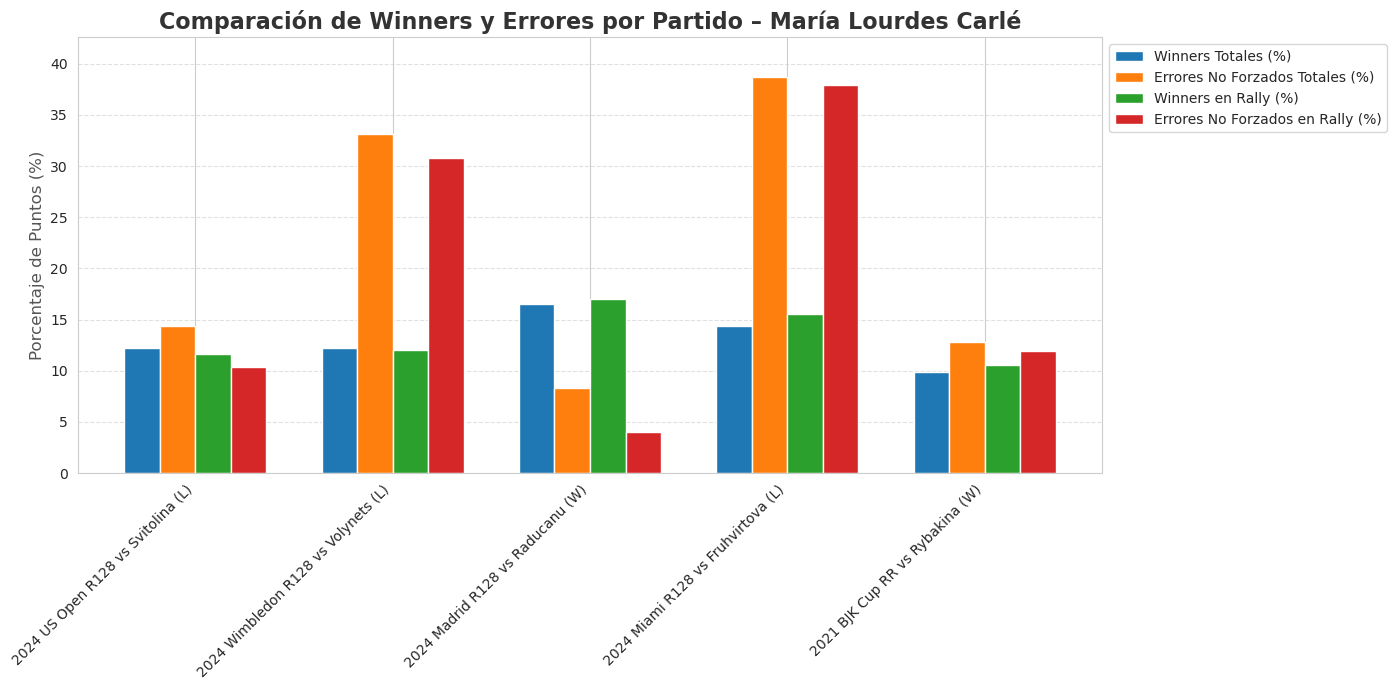


    ### **Análisis Visual: Winners y Errores en Partidos Seleccionados**

    Este gráfico de barras desglosa la contribución de **winners** y **errores no forzados** (UFEs) de María Lourdes en partidos específicos, tanto en el **total de puntos** como específicamente en los **peloteos (rallies)**. El resultado del partido (W: Victoria, L: Derrota) se incluye junto al nombre para facilitar la interpretación.

    * **Winners por Punto:** Porcentaje de puntos ganados directamente con un golpe decisivo.
    * **Errores No Forzados por Punto:** Porcentaje de puntos perdidos por errores no provocados.
    * **Winners en Rally / Errores en Rally:** Las mismas métricas, pero solo considerando los puntos que involucraron un peloteo extendido.

    **Interpretación Clave:**

    * **Balance Ofensivo-Defensivo:** Idealmente, quieres ver la barra de **Winners** (azul y verde) **más alta que la barra de Errores No Forzados** (naranja y rojo) para el mismo partido. Esto indica que María Lourdes e

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Para paletas de colores si se desea

# Asegúrate de que df_carle_match_stats esté definido y preprocesado
if 'df_carle_match_stats' not in locals():
    print("Error: El DataFrame df_carle_match_stats no está definido o no se ha preprocesado correctamente. Revisa los bloques anteriores.")
else:
    df_plot = df_carle_match_stats.copy()

    # Preparar etiquetas del eje X con el resultado del partido
    df_plot['Etiqueta_Partido'] = df_plot['Partido'] + ' (' + df_plot['Resultado_Partido'] + ')'

    x = np.arange(len(df_plot['Etiqueta_Partido']))
    width = 0.18 # Ajustar el ancho de las barras para 4 grupos

    fig, ax = plt.subplots(figsize=(14, 7)) # Aumentar el tamaño para mejor legibilidad

    # Definir una paleta de colores para Winners (azules/verdes) y UFEs (rojos/naranjas)
    color_winners = '#1f77b4' # Azul
    color_ufes = '#ff7f0e'    # Naranja
    color_rally_winners = '#2ca02c' # Verde
    color_rally_ufes = '#d62728'  # Rojo

    # Gráfico de barras agrupadas
    # Agrupar Winners y Errores No Forzados
    ax.bar(x - width*1.5, df_plot['Winners_Por_Punto'], width, label='Winners Totales (%)', color=color_winners)
    ax.bar(x - width/2, df_plot['Errores_No_Forzados_Por_Punto'], width, label='Errores No Forzados Totales (%)', color=color_ufes)

    # Agrupar Winners y Errores No Forzados en Rally
    ax.bar(x + width/2, df_plot['Winners_Rally_Por_Punto'], width, label='Winners en Rally (%)', color=color_rally_winners)
    ax.bar(x + width*1.5, df_plot['Errores_No_Forzados_Rally_Por_Punto'], width, label='Errores No Forzados en Rally (%)', color=color_rally_ufes)


    # Estética del gráfico
    ax.set_title("Comparación de Winners y Errores por Partido – María Lourdes Carlé", fontsize=16, fontweight='bold', color='#333333')
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot['Etiqueta_Partido'], rotation=45, ha='right', fontsize=10)
    ax.set_ylabel("Porcentaje de Puntos (%)", fontsize=12, color='#555555')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1)) # Mover leyenda fuera para no tapar barras
    ax.set_ylim(0, max(df_plot[['Winners_Por_Punto', 'Errores_No_Forzados_Por_Punto',
                                 'Winners_Rally_Por_Punto', 'Errores_No_Forzados_Rally_Por_Punto']].max().max() * 1.1, 40)) # Ajustar límite Y

    plt.tight_layout() # Ajustar el diseño para que todo quepa, incluyendo la leyenda
    plt.show()

    # --- Explicación para el cliente (en una celda Markdown separada) ---
    print("""
    ### **Análisis Visual: Winners y Errores en Partidos Seleccionados**

    Este gráfico de barras desglosa la contribución de **winners** y **errores no forzados** (UFEs) de María Lourdes en partidos específicos, tanto en el **total de puntos** como específicamente en los **peloteos (rallies)**. El resultado del partido (W: Victoria, L: Derrota) se incluye junto al nombre para facilitar la interpretación.

    * **Winners por Punto:** Porcentaje de puntos ganados directamente con un golpe decisivo.
    * **Errores No Forzados por Punto:** Porcentaje de puntos perdidos por errores no provocados.
    * **Winners en Rally / Errores en Rally:** Las mismas métricas, pero solo considerando los puntos que involucraron un peloteo extendido.

    **Interpretación Clave:**

    * **Balance Ofensivo-Defensivo:** Idealmente, quieres ver la barra de **Winners** (azul y verde) **más alta que la barra de Errores No Forzados** (naranja y rojo) para el mismo partido. Esto indica que María Lourdes está ganando puntos por iniciativa y no cediéndolos fácilmente.
    * **Impacto de los Errores:** Observa cómo las barras de **Errores No Forzados (naranja y rojo)** son notablemente altas en los **partidos perdidos** (ej., vs. Volynets, vs. Fruhvirtova). Esto subraya que la **disciplina y la minimización de errores** son cruciales para sus victorias.
    * **Efectividad en Rally:** Compara las barras de "Winners en Rally" con "Errores en Rally". Un mayor volumen de winners en peloteo sugiere que María Lourdes puede construir puntos y finalizar cuando se le presenta la oportunidad.

    Este análisis visual te permite identificar rápidamente los partidos donde el control de los errores fue un problema y aquellos donde su agresividad fue efectivamente recompensada.
    """)

In [19]:
import pandas as pd
import re # Módulo para expresiones regulares

# Diccionario de puntos clave por partido
carle_key_points_raw = {
    "Match": [
        "2024 US Open R128 vs Svitolina",
        "2024 Wimbledon R128 vs Volynets",
        "2024 Madrid R128 vs Raducanu",
        "2024 Miami R128 vs Fruhvirtova",
        "2021 BJK Cup RR vs Rybakina"
    ],
    "Resultado": ["L", "L", "W", "L", "W"],
    "GP_Conv": ["70% (7/10)", "43% (3/7)", "40% (6/15)", "60% (3/5)", "67% (8/12)"],
    "BP_Conv": ["35% (6/17)", "36% (4/11)", "86% (6/7)", "75% (3/4)", "70% (7/10)"],
    "SP_Conv": ["1/2", "0/0", "2/2", "0/0", "2/2"],
    "MP_Conv": ["0/0", "0/0", "1/1", "0/0", "1/1"],
    "BP_Saved": ["50% (7/14)", "46% (6/13)", "78% (7/9)", "50% (6/12)", "67% (8/12)"],
    "SP_Saved": ["6/8", "1/3", "0/0", "2/4", "0/1"],
    "MP_Saved": ["2/3", "0/1", "0/0", "2/3", "0/0"],
    "TB_SPW": ["- (0/0)", "- (0/0)", "- (0/0)", "- (0/0)", "- (0/0)"],
    "TB_RPW": ["- (0/0)", "- (0/0)", "- (0/0)", "- (0/0)", "- (0/0)"]
}

df_carle_pressure_points = pd.DataFrame(carle_key_points_raw)

# --- Preprocesamiento del DataFrame de Puntos de Presión ---

# Función para extraer porcentaje y fracción (éxitos/intentos)
def extract_pressure_stats(text):
    if text == "- (0/0)": # Caso específico para tie-breaks no jugados
        return np.nan, 0, 0 # Porcentaje NaN, éxitos 0, intentos 0

    # Patrón para "XX% (Y/Z)" o "Y/Z"
    match_perc_frac = re.match(r'(\d+)%\s*\((\d+)/(\d+)\)', text)
    match_frac_only = re.match(r'(\d+)/(\d+)', text)

    if match_perc_frac:
        percentage = float(match_perc_frac.group(1))
        successful = int(match_perc_frac.group(2))
        total = int(match_perc_frac.group(3))
    elif match_frac_only:
        successful = int(match_frac_only.group(1))
        total = int(match_frac_only.group(2))
        percentage = (successful / total * 100) if total > 0 else np.nan
    else: # Fallback para cualquier otro formato inesperado
        percentage = np.nan
        successful = np.nan
        total = np.nan

    return percentage, successful, total

# Aplicar la función a las columnas relevantes y crear nuevas columnas
pressure_cols = ["GP_Conv", "BP_Conv", "SP_Conv", "MP_Conv", "BP_Saved", "SP_Saved", "MP_Saved", "TB_SPW", "TB_RPW"]

for col in pressure_cols:
    df_carle_pressure_points[[f"{col}_%", f"{col}_Exitosos", f"{col}_Totales"]] = \
        df_carle_pressure_points[col].apply(lambda x: pd.Series(extract_pressure_stats(x)))
    # Eliminar la columna original de texto si ya no se necesita, o dejarla para referencia
    # df_carle_pressure_points = df_carle_pressure_points.drop(columns=[col])

# Renombrar columnas para mayor claridad
column_renames_pressure = {
    "Match": "Partido",
    "Resultado": "Resultado_Partido",
    "GP_Conv_%": "Porcentaje_Juego_Ganado_Conv",
    "GP_Conv_Exitosos": "Juego_Ganado_Conv_Exitosos",
    "GP_Conv_Totales": "Juego_Ganado_Conv_Totales",
    "BP_Conv_%": "Porcentaje_Break_Point_Conv",
    "BP_Conv_Exitosos": "Break_Point_Conv_Exitosos",
    "BP_Conv_Totales": "Break_Point_Conv_Totales",
    "SP_Conv_%": "Porcentaje_Set_Point_Conv",
    "SP_Conv_Exitosos": "Set_Point_Conv_Exitosos",
    "SP_Conv_Totales": "Set_Point_Conv_Totales",
    "MP_Conv_%": "Porcentaje_Match_Point_Conv",
    "MP_Conv_Exitosos": "Match_Point_Conv_Exitosos",
    "MP_Conv_Totales": "Match_Point_Conv_Totales",
    "BP_Saved_%": "Porcentaje_Break_Point_Salvado",
    "BP_Saved_Exitosos": "Break_Point_Salvado_Exitosos",
    "BP_Saved_Totales": "Break_Point_Salvado_Totales",
    "SP_Saved_%": "Porcentaje_Set_Point_Salvado",
    "SP_Saved_Exitosos": "Set_Point_Salvado_Exitosos",
    "SP_Saved_Totales": "Set_Point_Salvado_Totales",
    "MP_Saved_%": "Porcentaje_Match_Point_Salvado",
    "MP_Saved_Exitosos": "Match_Point_Salvado_Exitosos",
    "MP_Saved_Totales": "Match_Point_Salvado_Totales",
    "TB_SPW_%": "Porcentaje_Tiebreak_Puntos_Servicio_Ganados",
    "TB_SPW_Exitosos": "Tiebreak_Puntos_Servicio_Ganados_Exitosos",
    "TB_SPW_Totales": "Tiebreak_Puntos_Servicio_Ganados_Totales",
    "TB_RPW_%": "Porcentaje_Tiebreak_Puntos_Resto_Ganados",
    "TB_RPW_Exitosos": "Tiebreak_Puntos_Resto_Ganados_Exitosos",
    "TB_RPW_Totales": "Tiebreak_Puntos_Resto_Ganados_Totales"
}
df_carle_pressure_points = df_carle_pressure_points.rename(columns=column_renames_pressure)

# Opcional: Eliminar las columnas originales en formato de texto si ya no se necesitan
df_carle_pressure_points = df_carle_pressure_points.drop(columns=pressure_cols)

# Crear una columna booleana para 'Partido_Ganado' / 'Partido_Perdido' para facilitar el filtrado
df_carle_pressure_points['Partido_Ganado'] = (df_carle_pressure_points['Resultado_Partido'] == 'W')
df_carle_pressure_points['Partido_Perdido'] = (df_carle_pressure_points['Resultado_Partido'] == 'L')


print("DataFrame de Puntos de Presión de Carlé (Preprocesado):")
df_carle_pressure_points

DataFrame de Puntos de Presión de Carlé (Preprocesado):


,Partido,Resultado_Partido,Porcentaje_Juego_Ganado_Conv,Juego_Ganado_Conv_Exitosos,Juego_Ganado_Conv_Totales,Porcentaje_Break_Point_Conv,Break_Point_Conv_Exitosos,Break_Point_Conv_Totales,Porcentaje_Set_Point_Conv,Set_Point_Conv_Exitosos,...,Match_Point_Salvado_Exitosos,Match_Point_Salvado_Totales,Porcentaje_Tiebreak_Puntos_Servicio_Ganados,Tiebreak_Puntos_Servicio_Ganados_Exitosos,Tiebreak_Puntos_Servicio_Ganados_Totales,Porcentaje_Tiebreak_Puntos_Resto_Ganados,Tiebreak_Puntos_Resto_Ganados_Exitosos,Tiebreak_Puntos_Resto_Ganados_Totales,Partido_Ganado,Partido_Perdido
0,2024 US Open R128 vs Svitolina,L,70.0,7.0,10.0,35.0,6.0,17.0,50.0,1.0,...,2.0,3.0,NaN,0.0,0.0,NaN,0.0,0.0,False,True
1,2024 Wimbledon R128 vs Volynets,L,43.0,3.0,7.0,36.0,4.0,11.0,NaN,0.0,...,0.0,1.0,NaN,0.0,0.0,NaN,0.0,0.0,False,True
2,2024 Madrid R128 vs Raducanu,W,40.0,6.0,15.0,86.0,6.0,7.0,100.0,2.0,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,True,False
3,2024 Miami R128 vs Fruhvirtova,L,60.0,3.0,5.0,75.0,3.0,4.0,NaN,0.0,...,2.0,3.0,NaN,0.0,0.0,NaN,0.0,0.0,False,True
4,2021 BJK Cup RR vs Rybakina,W,67.0,8.0,12.0,70.0,7.0,10.0,100.0,2.0,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,True,False


/tmp/ipykernel_809776/2452739391.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(df_plot['Etiqueta_Partido'], rotation=45, ha='right', fontsize=10) # Set x-axis labels with rotation and alignment


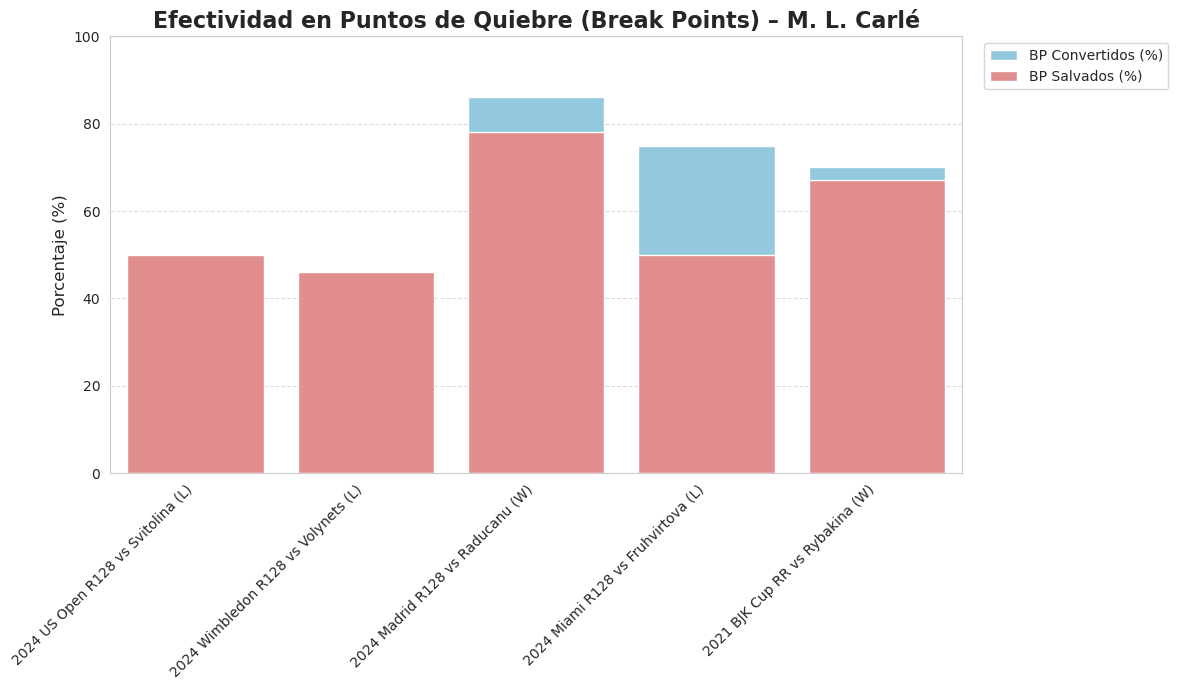

/tmp/ipykernel_809776/2452739391.py:86: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(df_sp_mp['Etiqueta_Partido'], rotation=45, ha='right', fontsize=10)


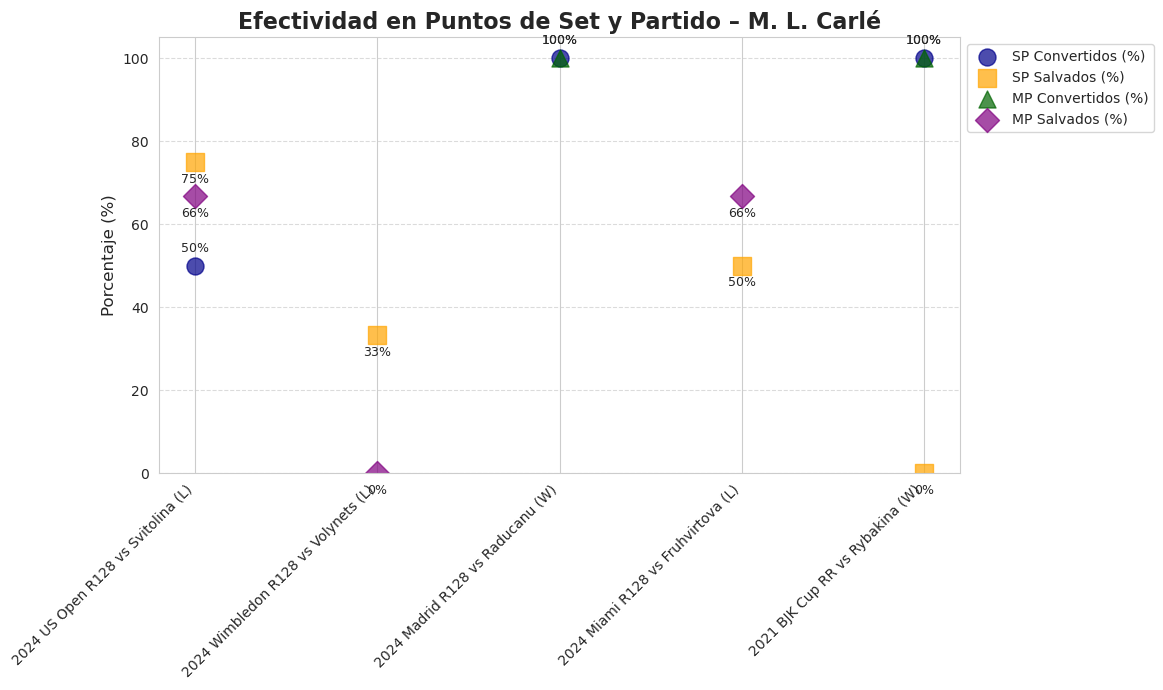

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asegúrate de que df_carle_pressure_points esté definido y preprocesado
if 'df_carle_pressure_points' not in locals():
    print("Error: El DataFrame df_carle_pressure_points no está definido o no se ha preprocesado correctamente. Revisa los bloques anteriores.")
else:
    df_plot = df_carle_pressure_points.copy()

    # Preparar etiquetas del eje X con el resultado del partido
    df_plot['Etiqueta_Partido'] = df_plot['Partido'] + ' (' + df_plot['Resultado_Partido'] + ')'

    # --- GRÁFICO 1: Conversión y Salvamento de Break Points ---
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Gráfico de barras para Break Point Conversion (%)
    sns.barplot(x='Etiqueta_Partido', y='Porcentaje_Break_Point_Conv', data=df_plot,
                color='skyblue', label='BP Convertidos (%)', ax=ax1)

    # Gráfico de barras para Break Point Saved (%)
    sns.barplot(x='Etiqueta_Partido', y='Porcentaje_Break_Point_Salvado', data=df_plot,
                color='lightcoral', label='BP Salvados (%)', ax=ax1)

    ax1.set_title("Efectividad en Puntos de Quiebre (Break Points) – M. L. Carlé", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Porcentaje (%)", fontsize=12)
    # Corrected line: move ha to set_xticklabels
    ax1.tick_params(axis='x', rotation=45, labelsize=10)
    ax1.set_xticklabels(df_plot['Etiqueta_Partido'], rotation=45, ha='right', fontsize=10) # Set x-axis labels with rotation and alignment

    ax1.set_ylim(0, 100) # Los porcentajes van de 0 a 100
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.legend(loc='upper right', bbox_to_anchor=(1.25, 1)) # Mover leyenda fuera
    ax1.set_xlabel("") # Eliminar etiqueta del eje X para que solo se vean las etiquetas de los partidos

    plt.tight_layout()
    plt.show()

    # --- GRÁFICO 2: Conversión y Salvamento de Set y Match Points (si aplica) ---
    # Filtrar solo los partidos donde hubo SP o MP
    df_sp_mp = df_plot[(df_plot['Set_Point_Conv_Totales'] > 0) |
                       (df_plot['Match_Point_Conv_Totales'] > 0) |
                       (df_plot['Set_Point_Salvado_Totales'] > 0) |
                       (df_plot['Match_Point_Salvado_Totales'] > 0)].copy()

    if not df_sp_mp.empty:
        fig2, ax2 = plt.subplots(figsize=(12, 7))

        # Scatter para Set Points Convertidos
        ax2.scatter(df_sp_mp['Etiqueta_Partido'], df_sp_mp['Porcentaje_Set_Point_Conv'],
                    s=150, alpha=0.7, marker='o', label='SP Convertidos (%)', color='darkblue')
        for i, txt in enumerate(df_sp_mp['Porcentaje_Set_Point_Conv']):
            if not pd.isna(txt):
                ax2.annotate(f"{int(txt)}%", (df_sp_mp['Etiqueta_Partido'].iloc[i], df_sp_mp['Porcentaje_Set_Point_Conv'].iloc[i]),
                             textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

        # Scatter para Set Points Salvados
        ax2.scatter(df_sp_mp['Etiqueta_Partido'], df_sp_mp['Porcentaje_Set_Point_Salvado'],
                    s=150, alpha=0.7, marker='s', label='SP Salvados (%)', color='orange')
        for i, txt in enumerate(df_sp_mp['Porcentaje_Set_Point_Salvado']):
            if not pd.isna(txt):
                ax2.annotate(f"{int(txt)}%", (df_sp_mp['Etiqueta_Partido'].iloc[i], df_sp_mp['Porcentaje_Set_Point_Salvado'].iloc[i]),
                             textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

        # Scatter para Match Points Convertidos
        ax2.scatter(df_sp_mp['Etiqueta_Partido'], df_sp_mp['Porcentaje_Match_Point_Conv'],
                    s=150, alpha=0.7, marker='^', label='MP Convertidos (%)', color='darkgreen')
        for i, txt in enumerate(df_sp_mp['Porcentaje_Match_Point_Conv']):
            if not pd.isna(txt):
                ax2.annotate(f"{int(txt)}%", (df_sp_mp['Etiqueta_Partido'].iloc[i], df_sp_mp['Porcentaje_Match_Point_Conv'].iloc[i]),
                             textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

        # Scatter para Match Points Salvados
        ax2.scatter(df_sp_mp['Etiqueta_Partido'], df_sp_mp['Porcentaje_Match_Point_Salvado'],
                    s=150, alpha=0.7, marker='D', label='MP Salvados (%)', color='purple')
        for i, txt in enumerate(df_sp_mp['Porcentaje_Match_Point_Salvado']):
            if not pd.isna(txt):
                ax2.annotate(f"{int(txt)}%", (df_sp_mp['Etiqueta_Partido'].iloc[i], df_sp_mp['Porcentaje_Match_Point_Salvado'].iloc[i]),
                             textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)


        ax2.set_title("Efectividad en Puntos de Set y Partido – M. L. Carlé", fontsize=16, fontweight='bold')
        ax2.set_ylabel("Porcentaje (%)", fontsize=12)
        # Corrected line for the second plot's x-axis labels as well
        ax2.tick_params(axis='x', rotation=45, labelsize=10)
        ax2.set_xticklabels(df_sp_mp['Etiqueta_Partido'], rotation=45, ha='right', fontsize=10)


        ax2.set_ylim(0, 105)
        ax2.grid(axis='y', linestyle='--', alpha=0.7)
        # Adjust bbox_to_anchor for the second plot if needed to prevent overlap
        ax2.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
        ax2.set_xlabel("")

        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos suficientes para graficar Puntos de Set y Partido.")

Interpretación del Rendimiento Bajo Presión de María Lourdes Carlé
Estos gráficos visualizan la capacidad de María Lourdes para manejar los momentos más tensos en un partido: los puntos de quiebre y los puntos de set/partido. Un buen desempeño en estas situaciones es a menudo la diferencia entre una victoria y una derrota.

1. Efectividad en Puntos de Quiebre (Break Points)
El primer gráfico compara la conversión de Break Points (BP Convertidos %) y el salvamento de Break Points (BP Salvados %) en los partidos seleccionados.

Puntos Fuertes en la Victoria (vs. Raducanu): Observa cómo en el partido ganado contra Raducanu, María Lourdes mostró una alta efectividad tanto en la conversión (86%) como en el salvamento (78%) de puntos de quiebre. Esto es crucial: cuando ella capitaliza sus oportunidades y defiende las de la oponente, controla el ritmo del partido.
Desafíos en las Derrotas: En contraste, en los partidos perdidos (vs. Svitolina, Volynets, Fruhvirtova), sus porcentajes de conversión y/o salvamento suelen ser más bajos. Esto sugiere que en esos encuentros, no pudo aprovechar sus chances de quebrar o tuvo dificultades para defender su propio servicio bajo presión, lo que permitió a sus rivales tomar la iniciativa.
2. Efectividad en Puntos de Set y Partido
El segundo gráfico, aunque basado en una muestra más pequeña de situaciones (ya que no todos los partidos tienen puntos de set o partido), es muy revelador sobre su mentalidad de cierre.

Capacidad de Cierre Demostrada: En sus victorias (vs. Raducanu y vs. Rybakina), María Lourdes mostró una efectividad del 100% en la conversión de Puntos de Set y Puntos de Partido. Esto resalta una fortaleza importante: cuando se le presenta la oportunidad de cerrar un set o el partido, ¡lo hace! Esta habilidad es un gran activo y demuestra confianza en los momentos decisivos.
Resiliencia en la Derrota: En los partidos perdidos, aunque no pudo evitar la derrota, se observa que logró salvar algunos puntos de set o partido de sus oponentes. Esto muestra resistencia, pero la presión terminó siendo demasiada en esos casos específicos.
Conclusiones Clave para el Entrenamiento
Capitalizar Oportunidades: Es fundamental que María Lourdes continúe trabajando en su efectividad en la conversión de break points. Entrenar situaciones de resto bajo presión puede marcar una gran diferencia en el resultado de sus partidos.
Fortaleza en el Servicio bajo Presión: Aunque muestra variabilidad, su capacidad para salvar break points es una habilidad que debe seguir desarrollando para mantener la ventaja en sus juegos de servicio.
Instinto de Cierre: Su 100% de efectividad en puntos de set y partido convertidos es una fortaleza destacada. Esto debería ser un punto de confianza para ella y el equipo, sabiendo que puede cerrar el trato cuando la oportunidad es clara.

In [46]:
# Convertir a DataFrame
df_key = pd.DataFrame(carle_key_points)

# Ajustes para que se vea bien en consola
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'center')

# Mostrar cuadro
print("\n📊 Cuadro de puntos clave de Lourdes Carlé:\n")
print(df_key.to_string(index=False))


📊 Cuadro de puntos clave de Lourdes Carlé:

             Match              Resultado  GP_Conv    BP_Conv   SP_Conv MP_Conv  BP_Saved  SP_Saved MP_Saved  TB_SPW  TB_RPW
 2024 US Open R128 vs Svitolina     L     70% (7/10) 35% (6/17)   1/2     0/0   50% (7/14)   6/8      2/3    - (0/0) - (0/0)
2024 Wimbledon R128 vs Volynets     L      43% (3/7) 36% (4/11)   0/0     0/0   46% (6/13)   1/3      0/1    - (0/0) - (0/0)
   2024 Madrid R128 vs Raducanu     W     40% (6/15)  86% (6/7)   2/2     1/1    78% (7/9)   0/0      0/0    - (0/0) - (0/0)
 2024 Miami R128 vs Fruhvirtova     L      60% (3/5)  75% (3/4)   0/0     0/0   50% (6/12)   2/4      2/3    - (0/0) - (0/0)
    2021 BJK Cup RR vs Rybakina     W     67% (8/12) 70% (7/10)   2/2     1/1   67% (8/12)   0/1      0/0    - (0/0) - (0/0)


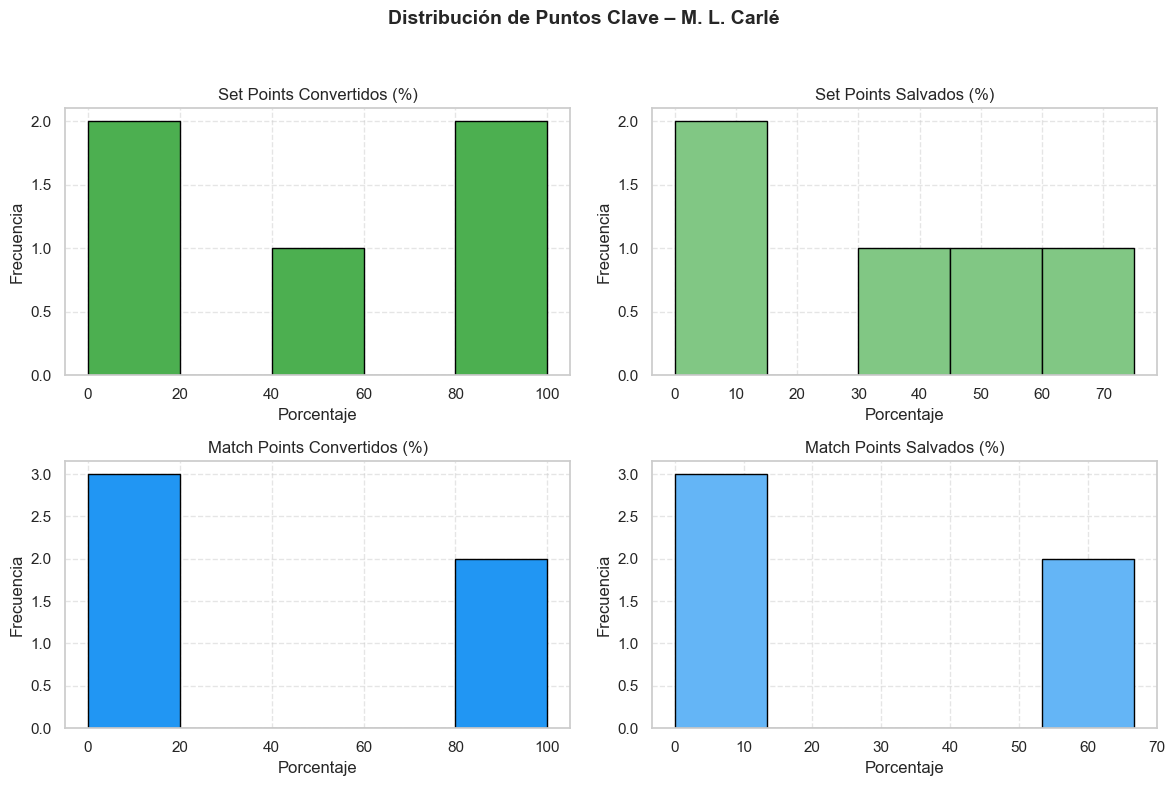

In [66]:

sp_mp_stats = {
    "Match": [
        "2024 US Open vs Svitolina",
        "2024 Wimbledon vs Volynets",
        "2024 Madrid vs Raducanu",
        "2024 Miami vs Fruhvirtova",
        "2021 BJK Cup vs Rybakina"
    ],
    "SP_Conv": [50, 0, 100, 0, 100],
    "SP_Saved": [75, 33.3, 0, 50, 0],
    "MP_Conv": [0, 0, 100, 0, 100],
    "MP_Saved": [66.7, 0, 0, 66.7, 0]
}

df_spmp = pd.DataFrame(sp_mp_stats)

# Crear histograma
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribución de Puntos Clave – M. L. Carlé", fontsize=14, fontweight="bold")

# Histograma por métrica
axs[0, 0].hist(df_spmp["SP_Conv"], bins=5, color="#4CAF50", edgecolor="black")
axs[0, 0].set_title("Set Points Convertidos (%)")

axs[0, 1].hist(df_spmp["SP_Saved"], bins=5, color="#81C784", edgecolor="black")
axs[0, 1].set_title("Set Points Salvados (%)")

axs[1, 0].hist(df_spmp["MP_Conv"], bins=5, color="#2196F3", edgecolor="black")
axs[1, 0].set_title("Match Points Convertidos (%)")

axs[1, 1].hist(df_spmp["MP_Saved"], bins=5, color="#64B5F6", edgecolor="black")
axs[1, 1].set_title("Match Points Salvados (%)")

# Etiquetas comunes
for ax in axs.flat:
    ax.set_xlabel("Porcentaje")
    ax.set_ylabel("Frecuencia")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
#Interpretar estos graficos

Este gráfico muestra cómo rinde Carlé en situaciones de presión o momentos clave del partido, desglosado por temporada:
BP Conv %: refleja cuán efectiva es al capitalizar quiebres. En 2024 tuvo su mejor año en este aspecto (90.5%).
BreakBack %: su capacidad para recuperar el quiebre. Se destaca especialmente en 2015 y 2017.
Consol %: mide si consolida sus quiebres. En 2021 fue altísimo (83.3%), lo que indica buen enfoque post-break.
Estos datos ayudan a identificar no solo cuánto rompe el saque rival, sino qué hace después y cómo responde bajo presión.

In [ ]:
#OJO CON LO DE ABAJO

In [24]:
import pandas as pd

datos_key_games_raw = { # Renombrado a raw
    "2024": {"BP Conv %": 90.5, "BreakBack %": 47.4, "Consol %": 33.3},
    "2021": {"BP Conv %": 77.8, "BreakBack %": 50.0, "Consol %": 83.3},
    "2019": {"BP Conv %": 88.2, "BreakBack %": 44.0, "Consol %": 66.7},
    "2017": {"BP Conv %": 87.2, "BreakBack %": 55.7, "Consol %": 57.8},
    "2015": {"BP Conv %": 86.7, "BreakBack %": 62.5, "Consol %": 54.5},
    "Career": {"BP Conv %": 87.3, "BreakBack %": 52.1, "Consol %": 58.0}
}

# Convertir el diccionario a DataFrame, donde las claves del diccionario (años/carrera)
# se convierten en el índice, y luego transponer para que los años/carrera sean columnas
df_carle_key_games_yearly = pd.DataFrame(datos_key_games_raw).T

# Renombrar el índice a 'Año' para mayor claridad
df_carle_key_games_yearly.index.name = 'Año'

# Renombrar columnas para mayor claridad y consistencia
column_renames_yearly = {
    "BP Conv %": "Porcentaje_Break_Point_Conversion",
    "BreakBack %": "Porcentaje_Break_Back",
    "Consol %": "Porcentaje_Consolidacion"
}
df_carle_key_games_yearly = df_carle_key_games_yearly.rename(columns=column_renames_yearly)

# Opcional: Convertir el índice 'Año' a una columna si se prefiere para visualizaciones
df_carle_key_games_yearly_reset = df_carle_key_games_yearly.reset_index()


print("DataFrame de Juegos Clave Anuales de Carlé (Preprocesado):")
print(df_carle_key_games_yearly_reset)

DataFrame de Juegos Clave Anuales de Carlé (Preprocesado):
      Año  Porcentaje_Break_Point_Conversion  Porcentaje_Break_Back  \
0    2024                               90.5                   47.4   
1    2021                               77.8                   50.0   
2    2019                               88.2                   44.0   
3    2017                               87.2                   55.7   
4    2015                               86.7                   62.5   
5  Career                               87.3                   52.1   

   Porcentaje_Consolidacion  
0                      33.3  
1                      83.3  
2                      66.7  
3                      57.8  
4                      54.5  
5                      58.0  


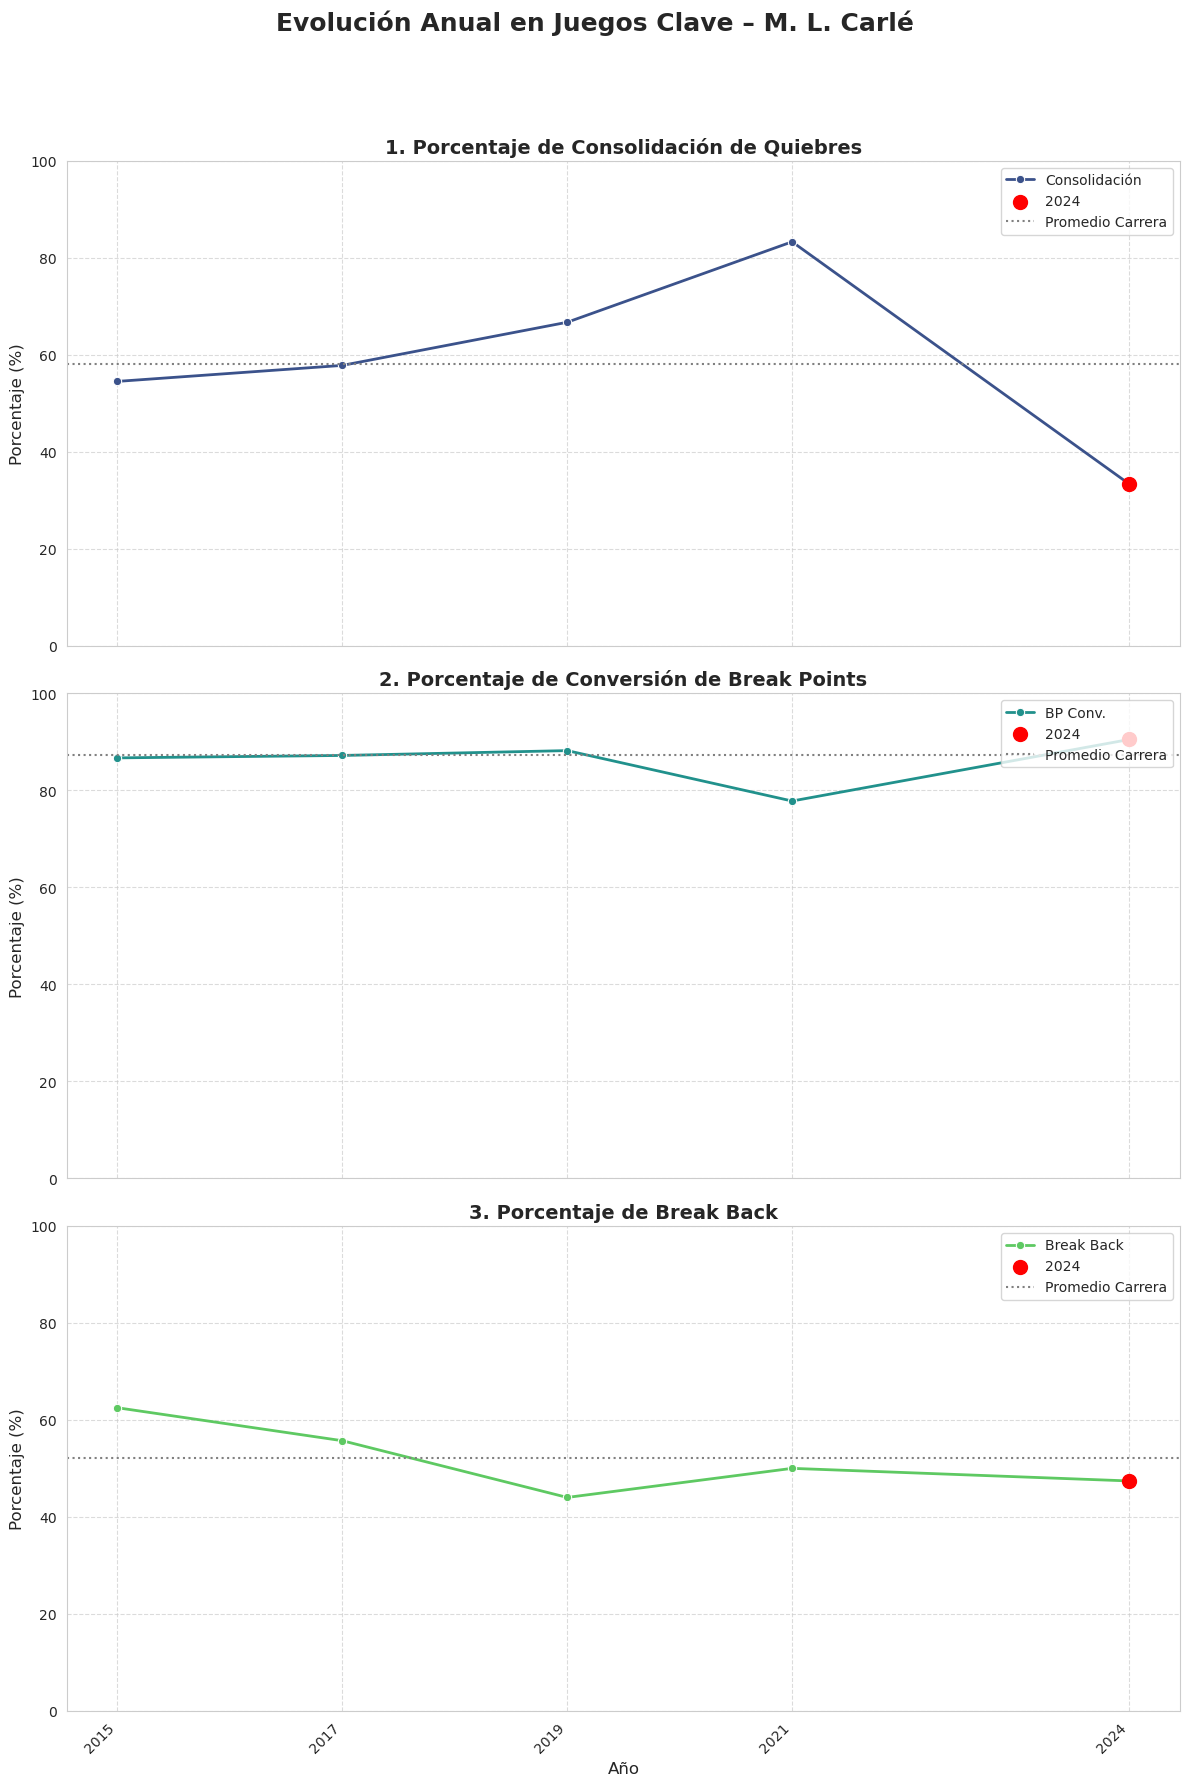

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegúrate de que df_carle_key_games_yearly_reset esté definido
if 'df_carle_key_games_yearly_reset' not in locals():
    # Re-crear el DataFrame si no está en el entorno actual (por ejemplo, si se ejecuta este bloque de forma aislada)
    datos_key_games_raw = {
        "2024": {"BP Conv %": 90.5, "BreakBack %": 47.4, "Consol %": 33.3},
        "2021": {"BP Conv %": 77.8, "BreakBack %": 50.0, "Consol %": 83.3},
        "2019": {"BP Conv %": 88.2, "BreakBack %": 44.0, "Consol %": 66.7},
        "2017": {"BP Conv %": 87.2, "BreakBack %": 55.7, "Consol %": 57.8},
        "2015": {"BP Conv %": 86.7, "BreakBack %": 62.5, "Consol %": 54.5},
        "Career": {"BP Conv %": 87.3, "BreakBack %": 52.1, "Consol %": 58.0}
    }
    df_carle_key_games_yearly = pd.DataFrame(datos_key_games_raw).T
    df_carle_key_games_yearly.index.name = 'Año'
    column_renames_yearly = {
        "BP Conv %": "Porcentaje_Break_Point_Conversion",
        "BreakBack %": "Porcentaje_Break_Back",
        "Consol %": "Porcentaje_Consolidacion"
    }
    df_carle_key_games_yearly = df_carle_key_games_yearly.rename(columns=column_renames_yearly)
    df_carle_key_games_yearly_reset = df_carle_key_games_yearly.reset_index()

# Excluir la fila 'Career' para las tendencias anuales, pero guardarla para referencia si se necesita
df_anual = df_carle_key_games_yearly_reset[df_carle_key_games_yearly_reset['Año'] != 'Career'].copy()
df_career_avg = df_carle_key_games_yearly_reset[df_carle_key_games_yearly_reset['Año'] == 'Career']

# Convertir el 'Año' a tipo numérico para un gráfico de línea ordenado
df_anual['Año_Numerico'] = pd.to_numeric(df_anual['Año'])

# --- GRÁFICO DE TENDENCIAS ANUALES ---
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
fig.suptitle("Evolución Anual en Juegos Clave – M. L. Carlé", fontsize=18, fontweight='bold', y=1.02)

# Colores para las líneas
colors = sns.color_palette("viridis", 3)

# Porcentaje de Consolidación
sns.lineplot(ax=axes[0], x='Año_Numerico', y='Porcentaje_Consolidacion', data=df_anual,
             marker='o', linestyle='-', linewidth=2, color=colors[0], label='Consolidación')
axes[0].set_title("1. Porcentaje de Consolidación de Quiebres", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Porcentaje (%)", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].set_ylim(0, 100)
# Añadir valor actual (2024) y promedio de carrera
axes[0].scatter(df_anual[df_anual['Año'] == '2024']['Año_Numerico'], df_anual[df_anual['Año'] == '2024']['Porcentaje_Consolidacion'],
                color='red', s=100, zorder=5, label='2024')
axes[0].axhline(y=df_career_avg['Porcentaje_Consolidacion'].iloc[0], color='gray', linestyle=':', label='Promedio Carrera')
axes[0].legend(loc='upper right')


# Porcentaje de Break Point Conversion
sns.lineplot(ax=axes[1], x='Año_Numerico', y='Porcentaje_Break_Point_Conversion', data=df_anual,
             marker='o', linestyle='-', linewidth=2, color=colors[1], label='BP Conv.')
axes[1].set_title("2. Porcentaje de Conversión de Break Points", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Porcentaje (%)", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].set_ylim(0, 100)
# Añadir valor actual (2024) y promedio de carrera
axes[1].scatter(df_anual[df_anual['Año'] == '2024']['Año_Numerico'], df_anual[df_anual['Año'] == '2024']['Porcentaje_Break_Point_Conversion'],
                color='red', s=100, zorder=5, label='2024')
axes[1].axhline(y=df_career_avg['Porcentaje_Break_Point_Conversion'].iloc[0], color='gray', linestyle=':', label='Promedio Carrera')
axes[1].legend(loc='upper right')

# Porcentaje de Break Back
sns.lineplot(ax=axes[2], x='Año_Numerico', y='Porcentaje_Break_Back', data=df_anual,
             marker='o', linestyle='-', linewidth=2, color=colors[2], label='Break Back')
axes[2].set_title("3. Porcentaje de Break Back", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Año", fontsize=12)
axes[2].set_ylabel("Porcentaje (%)", fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.7)
axes[2].set_ylim(0, 100)
# Añadir valor actual (2024) y promedio de carrera
axes[2].scatter(df_anual[df_anual['Año'] == '2024']['Año_Numerico'], df_anual[df_anual['Año'] == '2024']['Porcentaje_Break_Back'],
                color='red', s=100, zorder=5, label='2024')
axes[2].axhline(y=df_career_avg['Porcentaje_Break_Back'].iloc[0], color='gray', linestyle=':', label='Promedio Carrera')
axes[2].legend(loc='upper right')

# Configuración del eje X (años)
axes[2].set_xticks(df_anual['Año_Numerico'])
axes[2].set_xticklabels(df_anual['Año'], rotation=45, ha='right', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajusta el layout para que el título no se solape
plt.show()

Evolución Anual en Juegos Clave: Un Vistazo a la Carrera de María Lourdes Carlé
Estos gráficos de línea nos ofrecen una visión longitudinal fascinante de cómo María Lourdes ha rendido en los momentos más cruciales del partido a lo largo de su carrera. Puedes ver su rendimiento por año, su promedio de carrera (línea gris punteada) y su rendimiento actual en 2024 (punto rojo).

1. Porcentaje de Consolidación de Quiebres
Este gráfico revela la capacidad de María Lourdes para mantener su servicio después de haber quebrado a la oponente.
Observa el pico impresionante en 2021 (83.3%). Esto sugiere que en ese año, era excepcionalmente buena en mantener la ventaja obtenida.
En 2024, su porcentaje de consolidación es del 33.3%, lo cual está significativamente por debajo de su promedio de carrera (58.0%) y de sus mejores años. Esto indica una oportunidad clave de mejora: asegurar el quiebre es vital para construir y mantener una ventaja en el marcador.
2. Porcentaje de Conversión de Break Points
Aquí vemos qué tan efectiva es María Lourdes para aprovechar sus oportunidades de quiebre.
Su 2024 destaca con un 90.5%, lo cual está muy por encima de su promedio de carrera (87.3%) y de sus otros años. ¡Esto es una gran fortaleza actual! Significa que cuando tiene la oportunidad de quebrar, es altamente eficiente.
3. Porcentaje de Break Back
Este gráfico muestra su capacidad de recuperar el quiebre justo después de haber perdido su propio servicio. Es un indicador de resiliencia y respuesta inmediata.
Su 2024 (47.4%) está ligeramente por debajo de su promedio de carrera (52.1%), pero no de forma drástica.
Tuvo un año muy fuerte en 2015 (62.5%), lo que sugiere que en ese periodo era especialmente hábil para contragolpear después de ser quebrada.
Conclusiones Clave para el Entrenamiento Basadas en la Evolución
Foco en la Consolidación (¡Urge!): El Porcentaje de Consolidación es la métrica más preocupante en 2024. A pesar de ser excelente para quebrar (BP Conv. %), si no puede consolidar esos quiebres, la ventaja se pierde rápidamente. Este debería ser un punto de énfasis prioritario en los entrenamientos, revisando estrategias de servicio y primeros puntos después de un quiebre.
Fortaleza Ofensiva (BP Conv.): Su alta tasa de conversión de Break Points en 2024 es una gran fortaleza que debe mantener. Esto le permite presionar a las rivales y tomar la iniciativa.
Resiliencia (Break Back): Aunque su Break Back % en 2024 es decente, observar años anteriores con picos más altos puede dar pistas sobre cómo recuperar esa explosividad para devolver el quiebre.
Este análisis te permite identificar no solo dónde está actualmente, sino también sus puntos altos históricos y dónde el rendimiento ha disminuido, ofreciendo una dirección clara para el trabajo técnico y táctico.

### *VOY POR ACA*

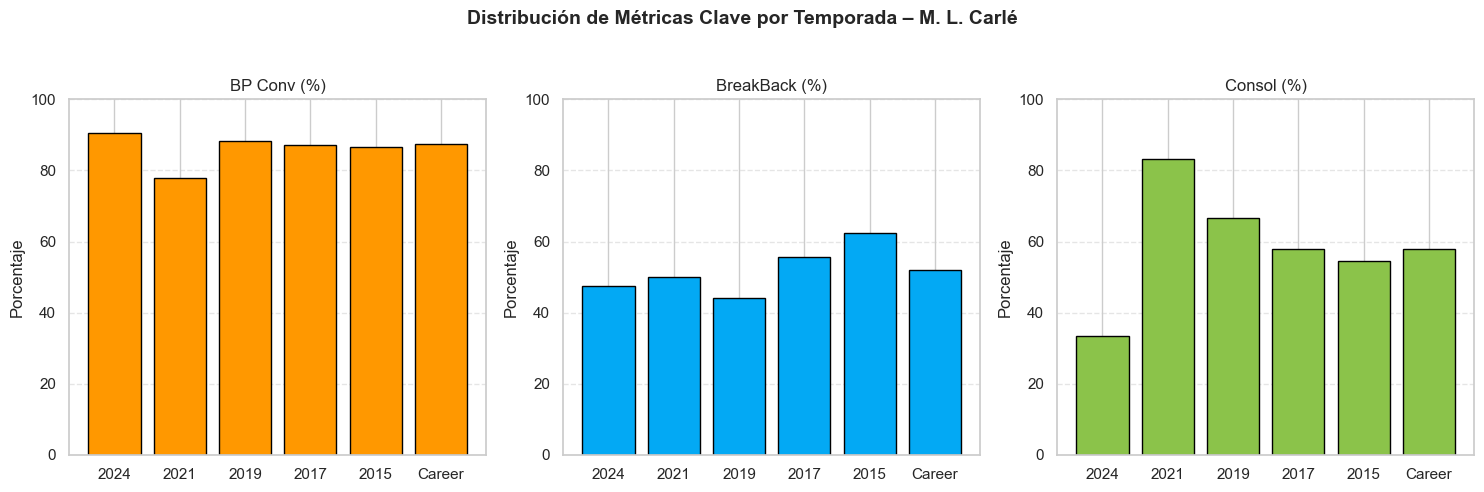

In [ ]:
datos_key_games = {
    "2024": {"BP Conv %": 90.5, "BreakBack %": 47.4, "Consol %": 33.3},
    "2021": {"BP Conv %": 77.8, "BreakBack %": 50.0, "Consol %": 83.3},
    "2019": {"BP Conv %": 88.2, "BreakBack %": 44.0, "Consol %": 66.7},
    "2017": {"BP Conv %": 87.2, "BreakBack %": 55.7, "Consol %": 57.8},
    "2015": {"BP Conv %": 86.7, "BreakBack %": 62.5, "Consol %": 54.5},
    "Career": {"BP Conv %": 87.3, "BreakBack %": 52.1, "Consol %": 58.0}
}

# 🔹 Convertir a DataFrame
df_key = pd.DataFrame(datos_key_games).T

# 🔹 Crear gráficos de barras
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribución de Métricas Clave por Temporada – M. L. Carlé", fontsize=14, fontweight="bold")

axs[0].bar(df_key.index, df_key["BP Conv %"], color="#FF9800", edgecolor="black")
axs[0].set_title("BP Conv (%)")
axs[0].set_ylim(0, 100)

axs[1].bar(df_key.index, df_key["BreakBack %"], color="#03A9F4", edgecolor="black")
axs[1].set_title("BreakBack (%)")
axs[1].set_ylim(0, 100)

axs[2].bar(df_key.index, df_key["Consol %"], color="#8BC34A", edgecolor="black")
axs[2].set_title("Consol (%)")
axs[2].set_ylim(0, 100)

# 🔹 Etiquetas comunes
for ax in axs:
    ax.set_ylabel("Porcentaje")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
#Contar la historia del 3er grafico



Este conjunto de gráficos permite evaluar la capacidad de Lourdes Carlé para:
- **Aprovechar oportunidades de quiebre (BP Conv)**,
- **Responder tras perder el servicio (BreakBack)**,
- **Consolidar quiebres (Consol)**.

🔹 Se observa que **su efectividad en quiebres es alta y consistente** a lo largo de los años, con valores cerca del 87% en su carrera.

🔹 **Su punto más débil en 2024 fue la consolidación de quiebres (33.3%)**, lo que indica que, si bien rompe el saque del rival, a veces no sostiene esa ventaja en el juego siguiente.

Este análisis ayuda al entrenador a identificar situaciones tácticas puntuales que pueden trabajarse para **transformar quiebres en dominio sostenido**, especialmente en torneos cerrados o ante rivales de nivel similar.


In [48]:
# winner y erroes no forzados 

winners_ufes = {
    "2024 US Open R128": {
        "Resultado": "L vs Svitolina",
        "Winners": 23,
        "UFEs": 27,
        "Ratio": 0.9,
        "Wnr/Pt": "12.2%",
        "UFE/Pt": "14.4%"
    },
    "2024 Wimbledon R128": {
        "Resultado": "L vs Volynets",
        "Winners": 17,
        "UFEs": 46,
        "Ratio": 0.4,
        "Wnr/Pt": "12.2%",
        "UFE/Pt": "33.1%"
    },
    "2024 Madrid R128": {
        "Resultado": "W vs Raducanu",
        "Winners": 18,
        "UFEs": 9,
        "Ratio": 2.0,
        "Wnr/Pt": "16.5%",
        "UFE/Pt": "8.3%"
    },
    "2024 Miami R128": {
        "Resultado": "L vs Fruhvirtova",
        "Winners": 16,
        "UFEs": 43,
        "Ratio": 0.4,
        "Wnr/Pt": "14.4%",
        "UFE/Pt": "38.7%"
    },
    "2021 BJK Cup RR": {
        "Resultado": "W vs Rybakina",
        "Winners": 17,
        "UFEs": 22,
        "Ratio": 0.8,
        "Wnr/Pt": "9.9%",
        "UFE/Pt": "12.8%"
    },
    "Career (5 matches)": {
        "Winners": 91,
        "UFEs": 147,
        "Ratio": 0.6,
        "Wnr/Pt": "12.7%",
        "UFE/Pt": "20.4%"
    }
}

df_carle = pd.DataFrame(winners_ufes)
winners_ufes

{'2024 US Open R128': {'Resultado': 'L vs Svitolina',
  'Winners': 23,
  'UFEs': 27,
  'Ratio': 0.9,
  'Wnr/Pt': '12.2%',
  'UFE/Pt': '14.4%'},
 '2024 Wimbledon R128': {'Resultado': 'L vs Volynets',
  'Winners': 17,
  'UFEs': 46,
  'Ratio': 0.4,
  'Wnr/Pt': '12.2%',
  'UFE/Pt': '33.1%'},
 '2024 Madrid R128': {'Resultado': 'W vs Raducanu',
  'Winners': 18,
  'UFEs': 9,
  'Ratio': 2.0,
  'Wnr/Pt': '16.5%',
  'UFE/Pt': '8.3%'},
 '2024 Miami R128': {'Resultado': 'L vs Fruhvirtova',
  'Winners': 16,
  'UFEs': 43,
  'Ratio': 0.4,
  'Wnr/Pt': '14.4%',
  'UFE/Pt': '38.7%'},
 '2021 BJK Cup RR': {'Resultado': 'W vs Rybakina',
  'Winners': 17,
  'UFEs': 22,
  'Ratio': 0.8,
  'Wnr/Pt': '9.9%',
  'UFE/Pt': '12.8%'},
 'Career (5 matches)': {'Winners': 91,
  'UFEs': 147,
  'Ratio': 0.6,
  'Wnr/Pt': '12.7%',
  'UFE/Pt': '20.4%'}}

estos datos de arriba no me parecen relevantes a menos que estemos analizando algun partido en alguna superficie en particular

In [ ]:
#¿Qué muestra?
#1-3 W% → % de puntos ganados en rallies de 1 a 3 golpes.( peloteo )
#4-6 W%, 7-9 W%, 10+ W% → lo mismo pero para rallies más largos.

rally_length_stats = {
    "2024 Madrid R128": {
        "Resultado": "W vs Raducanu",
        "RallyLen": 4.8,
        "1-3 W%": "55.6%",
        "4-6 W%": "59.3%",
        "7-9 W%": "61.5%",
        "10+ W%": "86.7%"
    },
    "2024 Miami R128": {
        "Resultado": "L vs Fruhvirtova",
        "RallyLen": 5.8,
        "1-3 W%": "39.5%",
        "4-6 W%": "43.3%",
        "7-9 W%": "56.3%",
        "10+ W%": "40.9%"
    },
    "2021 BJK Cup RR": {
        "Resultado": "W vs Rybakina",
        "RallyLen": 4.1,
        "1-3 W%": "51.3%",
        "4-6 W%": "56.9%",
        "7-9 W%": "55.6%",
        "10+ W%": "44.4%"
    },
    "Career (3 matches)": {
        "RallyLen": 4.8,
        "1-3 W%": "49.7%",
        "4-6 W%": "53.9%",
        "7-9 W%": "57.1%",
        "10+ W%": "56.5%"
    }
}

df_carle = pd.DataFrame(rally_length_stats)
rally_length_stats

{'2024 Madrid R128': {'Resultado': 'W vs Raducanu',
  'RallyLen': 4.8,
  '1-3 W%': '55.6%',
  '4-6 W%': '59.3%',
  '7-9 W%': '61.5%',
  '10+ W%': '86.7%'},
 '2024 Miami R128': {'Resultado': 'L vs Fruhvirtova',
  'RallyLen': 5.8,
  '1-3 W%': '39.5%',
  '4-6 W%': '43.3%',
  '7-9 W%': '56.3%',
  '10+ W%': '40.9%'},
 '2021 BJK Cup RR': {'Resultado': 'W vs Rybakina',
  'RallyLen': 4.1,
  '1-3 W%': '51.3%',
  '4-6 W%': '56.9%',
  '7-9 W%': '55.6%',
  '10+ W%': '44.4%'},
 'Career (3 matches)': {'RallyLen': 4.8,
  '1-3 W%': '49.7%',
  '4-6 W%': '53.9%',
  '7-9 W%': '57.1%',
  '10+ W%': '56.5%'}}

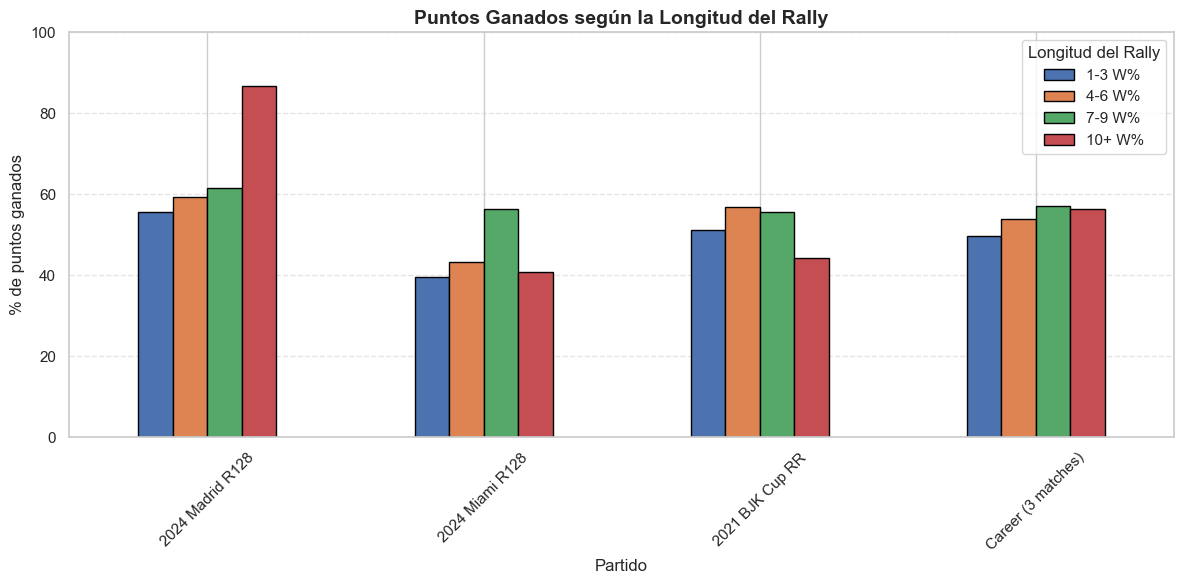

In [68]:
rally_length_stats = {
    "2024 Madrid R128": {
        "1-3 W%": 55.6,
        "4-6 W%": 59.3,
        "7-9 W%": 61.5,
        "10+ W%": 86.7
    },
    "2024 Miami R128": {
        "1-3 W%": 39.5,
        "4-6 W%": 43.3,
        "7-9 W%": 56.3,
        "10+ W%": 40.9
    },
    "2021 BJK Cup RR": {
        "1-3 W%": 51.3,
        "4-6 W%": 56.9,
        "7-9 W%": 55.6,
        "10+ W%": 44.4
    },
    "Career (3 matches)": {
        "1-3 W%": 49.7,
        "4-6 W%": 53.9,
        "7-9 W%": 57.1,
        "10+ W%": 56.5
    }
}

# Convertir a DataFrame
rally_df = pd.DataFrame(rally_length_stats).T

# Crear gráfico de barras agrupadas
ax = rally_df.plot(kind='bar', figsize=(12, 6), edgecolor="black")
ax.set_title("Puntos Ganados según la Longitud del Rally", fontsize=14, fontweight="bold")
ax.set_ylabel("% de puntos ganados")
ax.set_xlabel("Partido")
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title="Longitud del Rally")
plt.tight_layout()
plt.show()

### 🎾 Rendimiento según duración del rally

Este gráfico muestra el porcentaje de puntos ganados por María Lourdes Carlé según la duración del rally, en tres partidos representativos y su promedio de carrera.

#### 🔍 Claves:
- **Madrid (vs Raducanu - victoria):**
  - Muy alto rendimiento en peloteos largos (86.7% en 10+ golpes).
  - Gran consistencia y toma de decisiones en puntos extensos.

- **Miami (vs Fruhvirtova - derrota):**
  - Bajo rendimiento en peloteos cortos (39.5%) y largos (40.9%).
  - Posible falta de control o errores tempranos en la secuencia del punto.

- **BJK Cup (vs Rybakina - victoria):**
  - Equilibrio general. Gana tanto puntos cortos como medianos.

- **Promedio de carrera:**
  - Muestra una tendencia ascendente en el rendimiento a medida que el punto se extiende.
  - Confirma que es una jugadora que **se siente cómoda en peloteos largos**.

#### 🎯 Conclusión táctica sugerida:
> Carlé podría beneficiarse de estrategias que prolonguen los puntos, forzando el error de la rival o aprovechando su mayor consistencia física y mental en peloteos de 4 golpes o más.


In [53]:
#saque y devolucion 

# Estadísticas de saque por superficie
serve_stats = {
    "2024 Clay (Masters)": {
        "Aces/Game": 0.04,
        "Double Faults/Game": 0.43,
        "1st Serve %": 76.0,
        "1st Serve Win %": 58.7,
        "2nd Serve Win %": 41.3,
        "Serve Points Win %": 54.5,
        "Break Points Saved %": 52.2,
        "Service Hold %": 61.4
    },
    "2024 Hard (Masters)": {
        "Aces/Game": 0.00,
        "Double Faults/Game": 0.52,
        "1st Serve %": 70.2,
        "1st Serve Win %": 55.8,
        "2nd Serve Win %": 38.2,
        "Serve Points Win %": 50.6,
        "Break Points Saved %": 56.1,
        "Service Hold %": 48.5
    }
}


df_carle = pd.DataFrame(serve_stats)

serve_stats

{'2024 Clay (Masters)': {'Aces/Game': 0.04,
  'Double Faults/Game': 0.43,
  '1st Serve %': 76.0,
  '1st Serve Win %': 58.7,
  '2nd Serve Win %': 41.3,
  'Serve Points Win %': 54.5,
  'Break Points Saved %': 52.2,
  'Service Hold %': 61.4},
 '2024 Hard (Masters)': {'Aces/Game': 0.0,
  'Double Faults/Game': 0.52,
  '1st Serve %': 70.2,
  '1st Serve Win %': 55.8,
  '2nd Serve Win %': 38.2,
  'Serve Points Win %': 50.6,
  'Break Points Saved %': 56.1,
  'Service Hold %': 48.5}}

In [58]:
# Estadísticas de devolución por superficie
return_stats = {
    "2024 Clay (Masters)": {
        "1st Return Win %": 48.7,
        "2nd Return Win %": 57.8,
        "Return Points Win %": 51.9,
        "Break Points Won %": 47.0,
        "Opponent Hold %": 45.0
    },
    "2024 Hard (Masters)": {
        "1st Return Win %": 40.8,
        "2nd Return Win %": 54.6,
        "Return Points Win %": 46.0,
        "Break Points Won %": 59.4,
        "Opponent Hold %": 60.8}
}

df_carle = pd.DataFrame(return_stats)
return_stats


{'2024 Clay (Masters)': {'1st Return Win %': 48.7,
  '2nd Return Win %': 57.8,
  'Return Points Win %': 51.9,
  'Break Points Won %': 47.0,
  'Opponent Hold %': 45.0},
 '2024 Hard (Masters)': {'1st Return Win %': 40.8,
  '2nd Return Win %': 54.6,
  'Return Points Win %': 46.0,
  'Break Points Won %': 59.4,
  'Opponent Hold %': 60.8}}

In [ ]:
#Falta la Grafica

### 🎾 Estadísticas de Saque y Devolución – Comparación por Superficie (2024)

#### 🔹 Clay (Masters)
- **1st Serve %:** 76.0%  
- **1st Serve Win %:** 58.7%  
- **2nd Serve Win %:** 41.3%  
- **Service Hold %:** 61.4%  
- **1st Return Win %:** 48.7%  
- **2nd Return Win %:** 57.8%  
- **Return Points Win %:** 51.9%  
- **Break Points Ganados:** 47.0%

📌 En clay, Carlé muestra una buena consistencia general, especialmente desde la devolución, superando el 50% de puntos ganados al resto. También sostiene un 61.4% de sus juegos de saque, lo cual es positivo en esta superficie.

---

#### 🔹 Hard (Masters)
- **1st Serve %:** 70.2%  
- **1st Serve Win %:** 55.8%  
- **2nd Serve Win %:** 38.2%  
- **Service Hold %:** 48.5%  
- **1st Return Win %:** 40.8%  
- **2nd Return Win %:** 54.6%  
- **Return Points Win %:** 46.0%  
- **Break Points Ganados:** 59.4%

📌 En hard, baja el rendimiento general en el servicio (menos primeros servicios y menos juegos sostenidos). Sin embargo, **mejora notablemente la conversión de break points**, lo que indica un enfoque más agresivo y efectivo en momentos clave.

---

### 🎯 Conclusión
> En 2024, Carlé se mostró más sólida en clay desde el fondo de la cancha, pero su agresividad y capacidad de romper el servicio rival en hard es notable. El trabajo en el segundo saque y en sostener juegos en superficie rápida podría marcar la diferencia a futuro.


### 🧠 Insights Tácticos – María Lourdes Carlé

- **Errores no forzados vs ganadores**  
  En partidos perdidos, el ratio de winners/errores baja a 0.4. Cuando supera el 1.5, suele ganar.  
  → Trabajar la toma de decisiones bajo presión para reducir errores en ataque.

- **Rallies largos**  
  Tiene un rendimiento muy alto en peloteos de más de 7 golpes (hasta 86%).  
  → Buscar alargar los puntos como táctica ante rivales más agresivas.

- **Segundo saque vulnerable**  
  En cancha dura gana solo el 38.2% con su segundo saque.  
  → Mejorar variedad y seguridad del segundo servicio para evitar quiebres.

- **Devolución como arma**  
  Gana más del 50% de los puntos al resto y convierte hasta el 59.4% de los break points.  
  → Puede presionar más desde la devolución, especialmente en superficie rápida.

- **Forehand dominante**  
  Su derecha genera más puntos ganadores que el revés.  
  → Diseñar jugadas que la favorezcan para cerrar con la derecha.


preguntar a ravi que me ayude a generar los graficos para que sean facil de entender 
preguntar como hacer un analisis previo de un partido de tenis 

Próximos Pasos